# General

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares, curve_fit
from scipy.stats import poisson, chi2, f, mode
import math

In [3]:
#####################################################################################################

class CosmicWatchMeasurement:
    field_idx = {
        3 : 'times',
        6 : 'energies',
        7 : 'temperatures',
        8 : 'pressures',
        9 : 'dead_times',
        10 : 'coincident'
    }

    def __init__(self,
                 data_file,
                 only_coincident=True,
                 energy_cut=None):
        
        self._read_data(data_file)
        self.temperature_avg, self.temperature_std, self.temperature_max, self.temperature_min = self._get_average_param('temperatures')
        self.pressure_avg, self.pressure_std, self.pressure_max, self.pressure_min = self._get_average_param('pressures')

        if only_coincident:
            self._filter_coincident()
        if energy_cut is not None:
            self._filter_energy(energy_cut)

        self._get_rate()

    def _read_data(self,data_file):
        data = {
            field : [] for idx,field in self.field_idx.items()
        }
        with open(data_file, 'r') as f:
            for line in f.readlines():
            
                if line.startswith('#'):
                    continue
                line_data = line.split()
                for idx, field in self.field_idx.items():
                    data[field].append(float(line_data[idx]))

        for field in data:
            setattr(self,field,np.array(data[field]))

        self.total_time = self.times[-1]*1e-3

        self.dead_times = np.cumsum(self.dead_times)*1e-6
        self.times = self.times*1e-3 - self.dead_times

        self.live_time = self.times[-1]

    def _filter_coincident(self):
        mask = self.coincident == 1
        for field in self.field_idx.values():
            setattr(self,field,getattr(self,field)[mask])

    def _filter_energy(self, energy_cut):
        mask = self.energies > energy_cut
        for field in self.field_idx.values():
            setattr(self,field,getattr(self,field)[mask])

    def _get_rate(self):
        self.counts = self.times.size
        interval = self.times[-1] - self.times[0]

        self.rate = (self.counts-1) / interval * 1e3
        self.rate_err = np.sqrt(self.counts-1) / interval * 1e3

        self.rate_sys_err = (5 * self.total_time/3600/24) / interval * 1e3

    def _get_average_param(self,param):
        param_avg = np.mean(getattr(self, param))
        param_std = np.std(getattr(self, param))

        param_max = np.max(getattr(self, param))
        param_min = np.min(getattr(self, param))

        return param_avg, param_std, param_max, param_min

# 11-13

Text(0, 0.5, 'Rate')

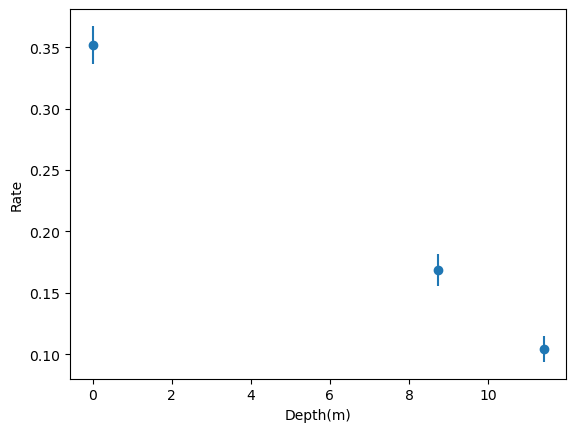

In [4]:
depths_11_13 = []
muon_rates_11_13 = []
muon_rate_errs_11_13 = []
data_11_13 = CosmicWatchMeasurement(data_file="submersion\\FileC017.txt", only_coincident=True)

mask_0 = (15*60 < data_11_13.times) & (data_11_13.times < 40*60)
depth_0 = 0
interval_0 = 40*60 - 15*60
depth_0_rate = len(data_11_13.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_13.times[mask_0])) / interval_0
depths_11_13.append(depth_0)
muon_rates_11_13.append(depth_0_rate)
muon_rate_errs_11_13.append(depth_0_rate_err)

mask_1 = (43*60 < data_11_13.times) & (data_11_13.times < 59*60)
depth_1 = 11.41
interval_1 = 59*60 - 43*60
depth_1_rate = len(data_11_13.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_13.times[mask_1])) / interval_1
depths_11_13.append(depth_1)
muon_rates_11_13.append(depth_1_rate)
muon_rate_errs_11_13.append(depth_1_rate_err)

mask_2 = (72*60 < data_11_13.times) & (data_11_13.times < 89*60)
depth_2 = 8.726
interval_2 = 89*60 - 73*60
depth_2_rate = len(data_11_13.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_13.times[mask_2])) / interval_2
depths_11_13.append(depth_2)
muon_rates_11_13.append(depth_2_rate)
muon_rate_errs_11_13.append(depth_2_rate_err)

plt.errorbar(depths_11_13, muon_rates_11_13, yerr=muon_rate_errs_11_13, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")

Text(0, 0.5, 'Rate')

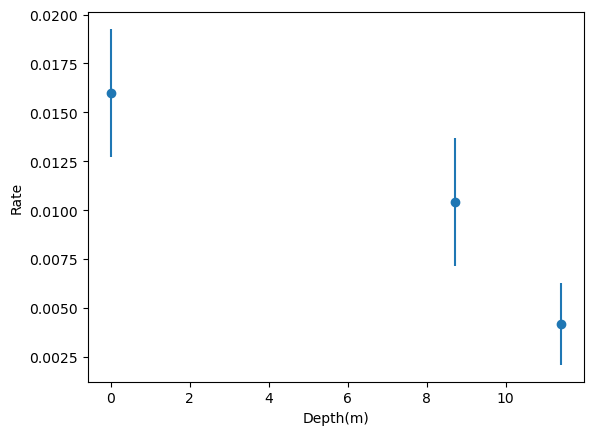

In [5]:
# adding energy cut 
muon_rates_11_13_e_cut = []
muon_rate_errs_11_13_e_cut = []

ws_energy_cut = (90 < data_11_13.energies)

depth_0_rate_e_cut = len(data_11_13.times[mask_0 & ws_energy_cut]) / interval_0
depth_0_rate_err_e_cut = np.sqrt(len(data_11_13.times[mask_0 & ws_energy_cut])) / interval_0
muon_rates_11_13_e_cut.append(depth_0_rate_e_cut)
muon_rate_errs_11_13_e_cut.append(depth_0_rate_err_e_cut)

depth_1_rate_e_cut = len(data_11_13.times[mask_1 & ws_energy_cut]) / interval_1
depth_1_rate_err_e_cut = np.sqrt(len(data_11_13.times[mask_1 & ws_energy_cut])) / interval_1
muon_rates_11_13_e_cut.append(depth_1_rate_e_cut)
muon_rate_errs_11_13_e_cut.append(depth_1_rate_err_e_cut)


depth_2_rate_e_cut = len(data_11_13.times[mask_2 & ws_energy_cut]) / interval_2
depth_2_rate_err_e_cut = np.sqrt(len(data_11_13.times[mask_2 & ws_energy_cut])) / interval_2
muon_rates_11_13_e_cut.append(depth_2_rate_e_cut)
muon_rate_errs_11_13_e_cut.append(depth_2_rate_err_e_cut)

plt.errorbar(depths_11_13, muon_rates_11_13_e_cut, yerr=muon_rate_errs_11_13_e_cut, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")

C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3880309202.py:9: RuntimeWarning: invalid value encountered in sqrt
  a_err_11_13 = np.sqrt(a_11_13-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3880309202.py:10: RuntimeWarning: invalid value encountered in sqrt
  b_err_11_13 = np.sqrt(b_11_13-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3880309202.py:11: RuntimeWarning: invalid value encountered in sqrt
  c_err_11_13 = np.sqrt(c_11_13-1)


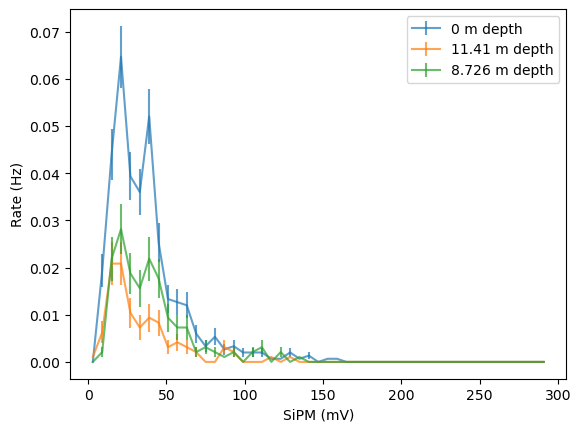

In [6]:
a_11_13,bins = np.histogram(data_11_13.energies[mask_0],bins = np.arange(0,300,300/50))
b_11_13,*_ = np.histogram(data_11_13.energies[mask_1], bins=bins)
c_11_13, *_ = np.histogram(data_11_13.energies[mask_2], bins=bins)
# d, *_ = np.histogram(data_11_19.energies[mask_3], bins=bins)
# e, *_ = np.histogram(data_11_19.energies[mask_4], bins=bins)
# f, *_ = np.histogram(data_11_25.energies[mask_5], bins=bins)
# g, *_ = np.histogram(data_11_25.energies[mask_6], bins=bins)

a_err_11_13 = np.sqrt(a_11_13-1)
b_err_11_13 = np.sqrt(b_11_13-1)
c_err_11_13 = np.sqrt(c_11_13-1)
# d_err = np.sqrt(d-1)
# e_err = np.sqrt(e-1)
# f_err = np.sqrt(f-1)
# g_err = np.sqrt(g-1)

# convert counts to rates 
a_11_13 = a_11_13/interval_0
b_11_13 = b_11_13/interval_1
c_11_13 = c_11_13/interval_2
# d = d/interval_3
# e = e/interval_4
# f = f/interval_5
# g = g/interval_6

plt.errorbar(0.5 * (bins[1:] + bins[:-1]),a_11_13, yerr = a_err_11_13/interval_0,label = '0 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),b_11_13, yerr = b_err_11_13/interval_1, label = '11.41 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),c_11_13, yerr = c_err_11_13/interval_2, label = '8.726 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),d, yerr = d_err/interval_3, label = '2.506 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),e, yerr = e_err/interval_4, label = '1.236 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),f, yerr = f_err/interval_5, label = '15 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),g, yerr = g_err/interval_6, label = '19.5 m depth', alpha = 0.7)

plt.ylabel('Rate (Hz)')
plt.xlabel('SiPM (mV)')
plt.legend()

Text(0, 0.5, 'Counts')

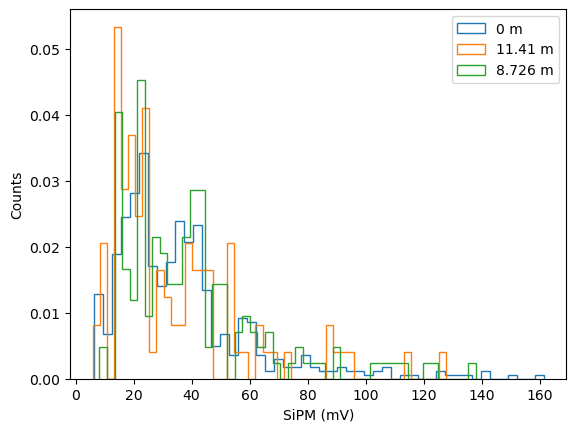

In [7]:
bottom = CosmicWatchMeasurement(data_file="submersion\\FileC018.txt", only_coincident=True)
top = CosmicWatchMeasurement(data_file="submersion\\FileC017.txt", only_coincident=True)

plt.hist(top.energies[mask_0], bins=50, histtype='step', label = '0 m', density=True)
plt.hist(top.energies[mask_1], bins=50, histtype='step', label = '11.41 m', density=True)
plt.hist(top.energies[mask_2], bins=50, histtype='step', label = '8.726 m', density=True)

# plt.hist(bottom.energies, bins=50, histtype='step', label = 'bottom detector')

# plt.hist(top.energies[:-1] + bottom.energies, bins=50, histtype='step')
plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

28.063118729096995 101301.3481103679
22.559435897435897 99167.97099999999
21.608085106382976 98953.1656382979


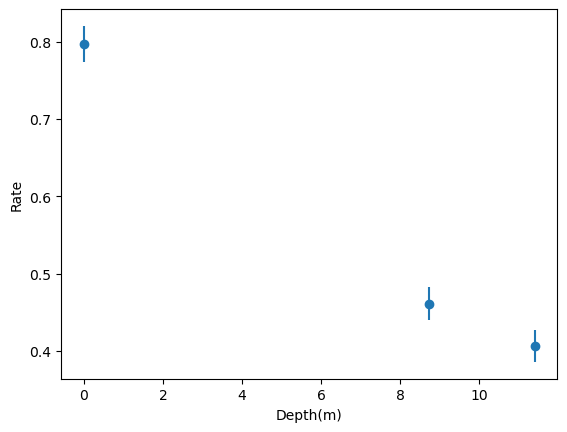

Text(0, 0.5, 'Counts')

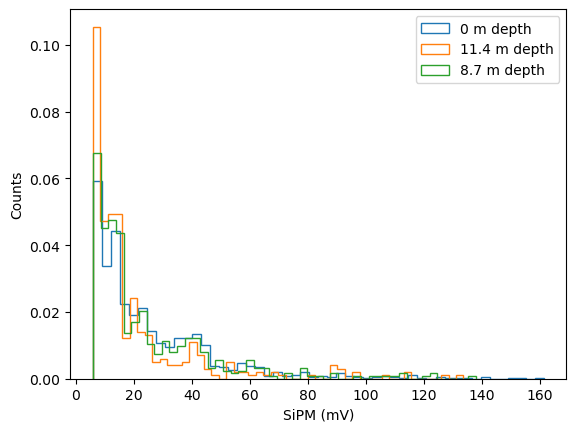

In [8]:
total_rates_11_13 = []
total_rate_errs_11_13 = []
data_11_13_all = CosmicWatchMeasurement(data_file="submersion\\FileC017.txt", only_coincident=False)

mask_0 = (15 * 60 < data_11_13_all.times) & (data_11_13_all.times < 40*60)
interval_0 = (40*60 - 15*60)
depth_0_rate = len(data_11_13_all.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_13_all.times[mask_0])) / interval_0
total_rates_11_13.append(depth_0_rate)
total_rate_errs_11_13.append(depth_0_rate_err)
print(np.mean(data_11_13_all.temperatures[mask_0]), np.mean(data_11_13_all.pressures[mask_0]))

mask_1 = (43*60 < data_11_13_all.times) & (data_11_13_all.times < 59*60)
interval_1 = (59*60 - 43*60)
depth_1_rate = len(data_11_13_all.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_13_all.times[mask_1])) / interval_1
total_rates_11_13.append(depth_1_rate)
total_rate_errs_11_13.append(depth_1_rate_err)
print(np.mean(data_11_13_all.temperatures[mask_1]), np.mean(data_11_13_all.pressures[mask_1]))

mask_2 = (72*60 < data_11_13_all.times) & (data_11_13_all.times < 89*60)
interval_2 = (89*60 - 72*60)
depth_2_rate = len(data_11_13_all.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_13_all.times[mask_2])) / interval_2
total_rates_11_13.append(depth_2_rate)
total_rate_errs_11_13.append(depth_2_rate_err)
print(np.mean(data_11_13_all.temperatures[mask_2]), np.mean(data_11_13_all.pressures[mask_2]))

plt.errorbar(depths_11_13, total_rates_11_13, yerr=total_rate_errs_11_13, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")
plt.show()

plt.hist(data_11_13_all.energies[mask_0], bins=50, histtype='step', label = '0 m depth', density=True)
plt.hist(data_11_13_all.energies[mask_1], bins=50, histtype='step', label = '11.4 m depth', density=True)
plt.hist(data_11_13_all.energies[mask_2], bins=50, histtype='step', label = '8.7 m depth', density=True)

plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

# 11-19

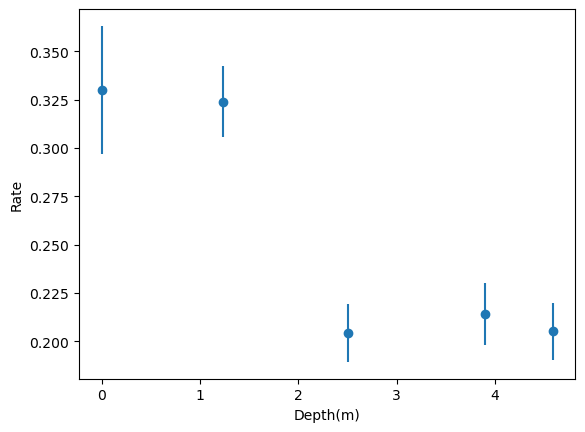

Text(0, 0.5, 'Counts')

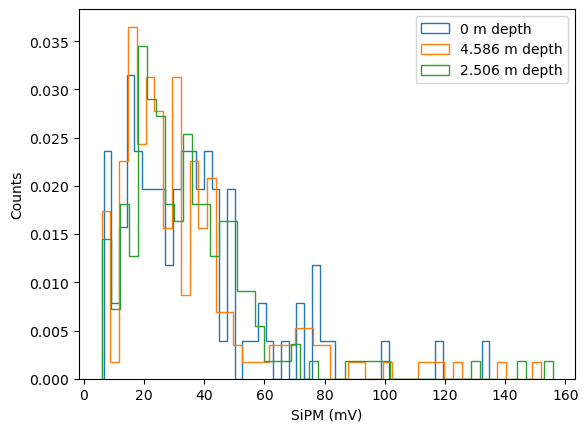

In [117]:
depths_11_19 = []
muon_rates_11_19 = []
muon_rate_errs_11_19 = []
data_11_19 = CosmicWatchMeasurement(data_file="submersion\\FileC029_1.txt", only_coincident=True)

mask_0 = (10 * 60 < data_11_19.times) & (data_11_19.times < 15*60)
depth_0 = 0
interval_0 = (15*60 - 10*60)
depth_0_rate = len(data_11_19.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_19.times[mask_0])) / interval_0
depths_11_19.append(depth_0)
muon_rates_11_19.append(depth_0_rate)
muon_rate_errs_11_19.append(depth_0_rate_err)

mask_1 = (17*60 < data_11_19.times) & (data_11_19.times < 33*60)
depth_1 = 4.586
interval_1 = (33*60 - 17*60)
depth_1_rate = len(data_11_19.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_19.times[mask_1])) / interval_1
depths_11_19.append(depth_1)
muon_rates_11_19.append(depth_1_rate)
muon_rate_errs_11_19.append(depth_1_rate_err)

mask_2 = (42*60 < data_11_19.times) & (data_11_19.times < 56*60)
depth_2 = 3.896
interval_2 = (56*60 - 42*60)
depth_2_rate = len(data_11_19.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_19.times[mask_2])) / interval_2
depths_11_19.append(depth_2)
muon_rates_11_19.append(depth_2_rate)
muon_rate_errs_11_19.append(depth_2_rate_err)

mask_3 = (59*60 < data_11_19.times) & (data_11_19.times < 74*60)
depth_3 = 2.506
interval_3 = (74*60 - 59*60)
depth_3_rate = len(data_11_19.times[mask_3]) / interval_3 
depth_3_rate_err = np.sqrt(len(data_11_19.times[mask_3])) / interval_3
depths_11_19.append(depth_3)
muon_rates_11_19.append(depth_3_rate)
muon_rate_errs_11_19.append(depth_3_rate_err)

mask_4 = (76*60 < data_11_19.times) & (data_11_19.times < 92*60)
depth_4 = 1.236
interval_4 = (92*60 - 76*60)
depth_4_rate = len(data_11_19.times[mask_4]) / interval_4
depth_4_rate_err = np.sqrt(len(data_11_19.times[mask_4])) / interval_4
depths_11_19.append(depth_4)
muon_rates_11_19.append(depth_4_rate)
muon_rate_errs_11_19.append(depth_4_rate_err)

plt.errorbar(depths_11_19, muon_rates_11_19, yerr=muon_rate_errs_11_19, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")
plt.show()

plt.hist(data_11_19.energies[mask_0], bins=50, histtype='step', label = '0 m depth', density=True)
plt.hist(data_11_19.energies[mask_1], bins=50, histtype='step', label = '4.586 m depth', density=True)
# plt.hist(data_11_19.energies[mask_2], bins=50, histtype='step', label = '3.896 m depth', density=True)
plt.hist(data_11_19.energies[mask_3], bins=50, histtype='step', label = '2.506 m depth', density=True)
# plt.hist(data_11_19.energies[mask_4], bins=50, histtype='step', label = '1.236 m depth', density=True)
plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

Text(0, 0.5, 'Rate')

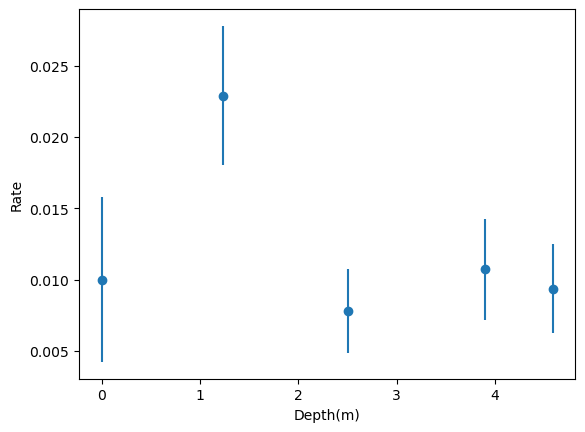

In [119]:
# adding energy cut 
muon_rates_11_19_e_cut = []
muon_rate_errs_11_19_e_cut = []

ws_energy_cut = (90 < data_11_19.energies)

depth_0_rate_e_cut = len(data_11_19.times[mask_0 & ws_energy_cut]) / interval_0
depth_0_rate_err_e_cut = np.sqrt(len(data_11_19.times[mask_0 & ws_energy_cut])) / interval_0
muon_rates_11_19_e_cut.append(depth_0_rate_e_cut)
muon_rate_errs_11_19_e_cut.append(depth_0_rate_err_e_cut)

depth_1_rate_e_cut = len(data_11_19.times[mask_1 & ws_energy_cut]) / interval_1
depth_1_rate_err_e_cut = np.sqrt(len(data_11_19.times[mask_1 & ws_energy_cut])) / interval_1
muon_rates_11_19_e_cut.append(depth_1_rate_e_cut)
muon_rate_errs_11_19_e_cut.append(depth_1_rate_err_e_cut)

depth_2_rate_e_cut = len(data_11_19.times[mask_2 & ws_energy_cut]) / interval_2
depth_2_rate_err_e_cut = np.sqrt(len(data_11_19.times[mask_2 & ws_energy_cut])) / interval_2
muon_rates_11_19_e_cut.append(depth_2_rate_e_cut)
muon_rate_errs_11_19_e_cut.append(depth_2_rate_err_e_cut)

depth_3_rate_e_cut = len(data_11_19.times[mask_3 & ws_energy_cut]) / interval_3
depth_3_rate_err_e_cut = np.sqrt(len(data_11_19.times[mask_3 & ws_energy_cut])) / interval_3
muon_rates_11_19_e_cut.append(depth_3_rate_e_cut)
muon_rate_errs_11_19_e_cut.append(depth_3_rate_err_e_cut)

depth_4_rate_e_cut = len(data_11_19.times[mask_4 & ws_energy_cut]) / interval_4
depth_4_rate_err_e_cut = np.sqrt(len(data_11_19.times[mask_4 & ws_energy_cut])) / interval_4
muon_rates_11_19_e_cut.append(depth_4_rate_e_cut)
muon_rate_errs_11_19_e_cut.append(depth_4_rate_err_e_cut)

plt.errorbar(depths_11_19, muon_rates_11_19_e_cut, yerr=muon_rate_errs_11_19_e_cut, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")

Text(0, 0.5, 'Counts')

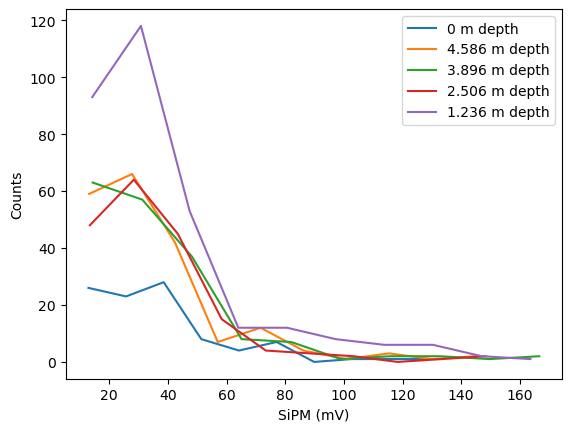

In [10]:
cnts_0, bins_0 = np.histogram(data_11_19.energies[mask_0])
cnts_1, bins_1 = np.histogram(data_11_19.energies[mask_1])
cnts_2, bins_2 = np.histogram(data_11_19.energies[mask_2])
cnts_3, bins_3 = np.histogram(data_11_19.energies[mask_3])
cnts_4, bins_4 = np.histogram(data_11_19.energies[mask_4])

bin_cs_0 = 0.5 * (bins_0[1:] + bins_0[:-1])
bin_cs_1 = 0.5 * (bins_1[1:] + bins_1[:-1])
bin_cs_2 = 0.5 * (bins_2[1:] + bins_2[:-1])
bin_cs_3 = 0.5 * (bins_3[1:] + bins_3[:-1])
bin_cs_4 = 0.5 * (bins_4[1:] + bins_4[:-1])

plt.plot(bin_cs_0, cnts_0, label = '0 m depth')
plt.plot(bin_cs_1, cnts_1, label = '4.586 m depth')
plt.plot(bin_cs_2, cnts_2, label = '3.896 m depth')
plt.plot(bin_cs_3, cnts_3, label = '2.506 m depth')
plt.plot(bin_cs_4, cnts_4, label = '1.236 m depth')

# plt.plot(bin_cs_0, np.cumsum(cnts_0)/np.sum(cnts_0), label = '0 m depth')
# plt.plot(bin_cs_1, np.cumsum(cnts_1)/np.sum(cnts_1), label = '4.586 m depth')
# plt.plot(bin_cs_2, np.cumsum(cnts_2)/np.sum(cnts_2), label = '3.896 m depth')
# plt.plot(bin_cs_3, np.cumsum(cnts_3)/np.sum(cnts_3), label = '2.506 m depth')
# plt.plot(bin_cs_4, np.cumsum(cnts_4)/np.sum(cnts_4), label = '1.236 m depth')

plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

C:\Users\megan\AppData\Local\Temp\ipykernel_21748\2933865252.py:9: RuntimeWarning: invalid value encountered in sqrt
  a_err_11_19 = np.sqrt(a_11_19-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\2933865252.py:10: RuntimeWarning: invalid value encountered in sqrt
  b_err_11_19 = np.sqrt(b_11_19-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\2933865252.py:11: RuntimeWarning: invalid value encountered in sqrt
  c_err_11_19 = np.sqrt(c_11_19-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\2933865252.py:12: RuntimeWarning: invalid value encountered in sqrt
  d_err_11_19 = np.sqrt(d_11_19-1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\2933865252.py:13: RuntimeWarning: invalid value encountered in sqrt
  e_err_11_19 = np.sqrt(e_11_19-1)


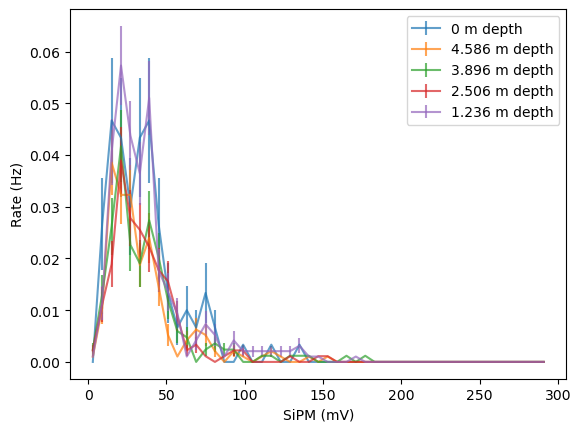

In [11]:
a_11_19,bins = np.histogram(data_11_19.energies[mask_0],bins = np.arange(0,300,300/50))
b_11_19,*_ = np.histogram(data_11_19.energies[mask_1], bins=bins)
c_11_19, *_ = np.histogram(data_11_19.energies[mask_2], bins=bins)
d_11_19, *_ = np.histogram(data_11_19.energies[mask_3], bins=bins)
e_11_19, *_ = np.histogram(data_11_19.energies[mask_4], bins=bins)
# f, *_ = np.histogram(data_11_25.energies[mask_5], bins=bins)
# g, *_ = np.histogram(data_11_25.energies[mask_6], bins=bins)

a_err_11_19 = np.sqrt(a_11_19-1)
b_err_11_19 = np.sqrt(b_11_19-1)
c_err_11_19 = np.sqrt(c_11_19-1)
d_err_11_19 = np.sqrt(d_11_19-1)
e_err_11_19 = np.sqrt(e_11_19-1)
# f_err = np.sqrt(f-1)
# g_err = np.sqrt(g-1)

# convert counts to rates 
a_11_19 = a_11_19/interval_0
b_11_19 = b_11_19/interval_1
c_11_19 = c_11_19/interval_2
d_11_19 = d_11_19/interval_3
e_11_19 = e_11_19/interval_4
# f = f/interval_5
# g = g/interval_6

plt.errorbar(0.5 * (bins[1:] + bins[:-1]),a_11_19, yerr = a_err_11_19/interval_0,label = '0 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),b_11_19, yerr = b_err_11_19/interval_1, label = '4.586 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),c_11_19, yerr = c_err_11_19/interval_2, label = '3.896 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),d_11_19, yerr = d_err_11_19/interval_3, label = '2.506 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),e_11_19, yerr = e_err_11_19/interval_4, label = '1.236 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),f, yerr = f_err/interval_5, label = '15 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),g, yerr = g_err/interval_6, label = '19.5 m depth', alpha = 0.7)

plt.ylabel('Rate (Hz)')
plt.xlabel('SiPM (mV)')
plt.legend()

30.394804469273748 103272.32952513966
25.99929018789144 99269.89185803759
18.9401880877743 97619.42877742946
16.854233128834355 97226.28226993865
15.777047970479705 97030.23813653135


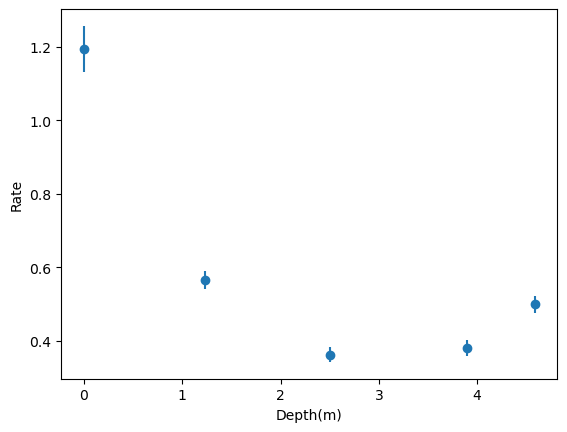

Text(0, 0.5, 'Counts')

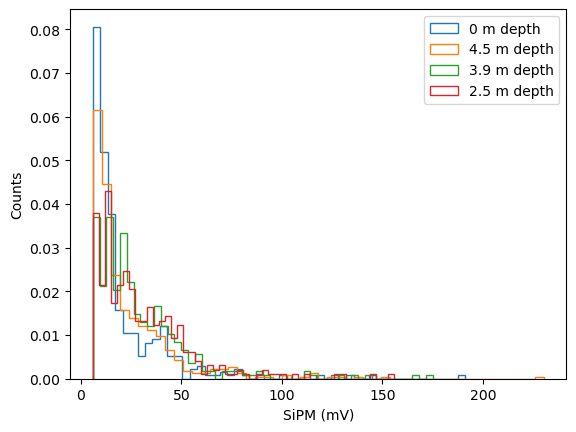

In [12]:
total_rates_11_19 = []
total_rate_errs_11_19 = []
data_11_19_all = CosmicWatchMeasurement(data_file="submersion\\FileC029_1.txt", only_coincident=False)

mask_0 = (10 * 60 < data_11_19_all.times) & (data_11_19_all.times < 15*60)
interval_0 = (15*60 - 10*60)
depth_0_rate = len(data_11_19_all.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_19_all.times[mask_0])) / interval_0
total_rates_11_19.append(depth_0_rate)
total_rate_errs_11_19.append(depth_0_rate_err)
print(np.mean(data_11_19_all.temperatures[mask_0]), np.mean(data_11_19_all.pressures[mask_0]))

mask_1 = (17*60 < data_11_19_all.times) & (data_11_19_all.times < 33*60)
interval_1 = (33*60 - 17*60)
depth_1_rate = len(data_11_19_all.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_19_all.times[mask_1])) / interval_1
total_rates_11_19.append(depth_1_rate)
total_rate_errs_11_19.append(depth_1_rate_err)
print(np.mean(data_11_19_all.temperatures[mask_1]), np.mean(data_11_19_all.pressures[mask_1]))

mask_2 = (42*60 < data_11_19_all.times) & (data_11_19_all.times < 56*60)
interval_2 = (56*60 - 42*60)
depth_2_rate = len(data_11_19_all.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_19_all.times[mask_2])) / interval_2
total_rates_11_19.append(depth_2_rate)
total_rate_errs_11_19.append(depth_2_rate_err)
print(np.mean(data_11_19_all.temperatures[mask_2]), np.mean(data_11_19_all.pressures[mask_2]))

mask_3 = (59*60 < data_11_19_all.times) & (data_11_19_all.times < 74*60)
interval_3 = (74*60 - 59*60)
depth_3_rate = len(data_11_19_all.times[mask_3]) / interval_3 
depth_3_rate_err = np.sqrt(len(data_11_19_all.times[mask_3])) / interval_3
total_rates_11_19.append(depth_3_rate)
total_rate_errs_11_19.append(depth_3_rate_err)
print(np.mean(data_11_19_all.temperatures[mask_3]), np.mean(data_11_19_all.pressures[mask_3]))

mask_4 = (76*60 < data_11_19_all.times) & (data_11_19_all.times < 92*60)
interval_4 = (92*60 - 76*60)
depth_4_rate = len(data_11_19_all.times[mask_4]) / interval_4
depth_4_rate_err = np.sqrt(len(data_11_19_all.times[mask_4])) / interval_4
total_rates_11_19.append(depth_4_rate)
total_rate_errs_11_19.append(depth_4_rate_err)
print(np.mean(data_11_19_all.temperatures[mask_4]), np.mean(data_11_19_all.pressures[mask_4]))

plt.errorbar(depths_11_19, total_rates_11_19, yerr=total_rate_errs_11_19, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")
plt.show()

plt.hist(data_11_19_all.energies[mask_0], bins=50, histtype='step', label = '0 m depth', density=True)
plt.hist(data_11_19_all.energies[mask_1], bins=50, histtype='step', label = '4.5 m depth', density=True)
plt.hist(data_11_19_all.energies[mask_2], bins=50, histtype='step', label = '3.9 m depth', density=True)
plt.hist(data_11_19_all.energies[mask_3], bins=50, histtype='step', label = '2.5 m depth', density=True)
# plt.hist(data_11_19_all.energies[mask_4], bins=50, histtype='step', label = '12.5 m depth', density=True)

plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

# 11-25

In [13]:
data_11_25_top = CosmicWatchMeasurement(data_file="submersion\\Top_Cos_Watch_11_25_25.txt", only_coincident=True)
data_11_25_bot = CosmicWatchMeasurement(data_file="submersion\\Bot_Cos_Watch_11_25_25.txt", only_coincident=True)
data_11_25_bot.counts,data_11_25_bot.counts

(2089, 2089)

13.857144906743185 103280.81373027258
16.455106382978723 104006.7960425532
16.871006711409393 104104.1112080537
17.092676056338032 104150.76070422535
17.136293706293706 104113.48062937064
16.22739336492891 103720.37720379149
17.166729323308267 104150.44669172932


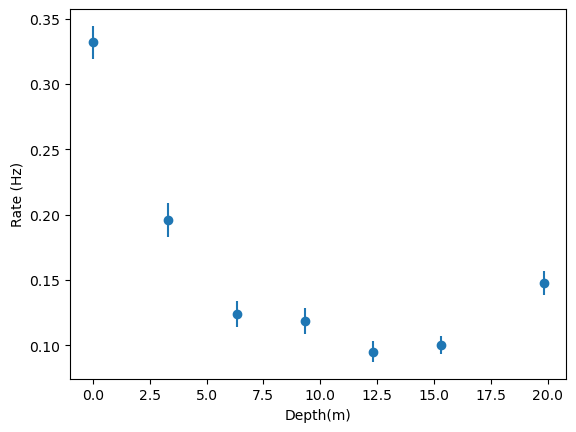

Text(0, 0.5, 'Spectra')

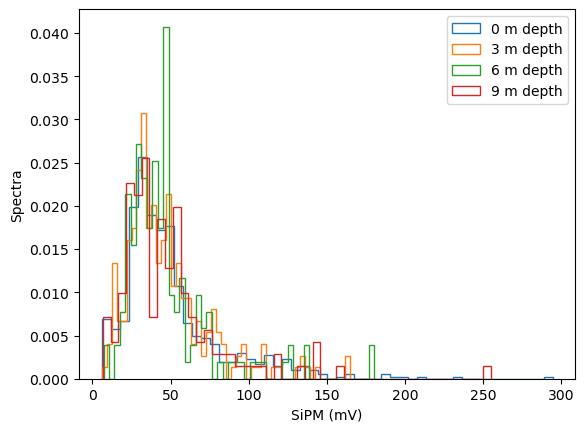

In [109]:
depths_11_25 = []
muon_rates_11_25 = []
muon_rate_errs_11_25 = []
data_11_25 = CosmicWatchMeasurement(data_file="submersion\\Top_Cos_Watch_11_25_25.txt", only_coincident=True)

mask_0 = (0 * 60 < data_11_25.times) & (data_11_25.times < 35*60)
depth_0 = 0
interval_0 = (35*60 - 0*60)
depth_0_rate = len(data_11_25.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_25.times[mask_0])) / interval_0
depths_11_25.append(depth_0)
muon_rates_11_25.append(depth_0_rate)
muon_rate_errs_11_25.append(depth_0_rate_err)
print(np.mean(data_11_25.temperatures[mask_0]), np.mean(data_11_25.pressures[mask_0]))

mask_1 = (35*60 < data_11_25.times) & (data_11_25.times < 55*60)
depth_1 = 3 + 0.34 - 0.014 
interval_1 = (55*60 - 35*60)
depth_1_rate = len(data_11_25.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_25.times[mask_1])) / interval_1
depths_11_25.append(depth_1)
muon_rates_11_25.append(depth_1_rate)
muon_rate_errs_11_25.append(depth_1_rate_err)
print(np.mean(data_11_25.temperatures[mask_1]), np.mean(data_11_25.pressures[mask_1]))

mask_2 = (55*60 < data_11_25.times) & (data_11_25.times < 75*60)
depth_2 = 6 + 0.34 - 0.014 
interval_2 = (75*60 - 55*60)
depth_2_rate = len(data_11_25.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_25.times[mask_2])) / interval_2
depths_11_25.append(depth_2)
muon_rates_11_25.append(depth_2_rate)
muon_rate_errs_11_25.append(depth_2_rate_err)
print(np.mean(data_11_25.temperatures[mask_2]), np.mean(data_11_25.pressures[mask_2]))

mask_3 = (75*60 < data_11_25.times) & (data_11_25.times < 95*60)
depth_3 = 9 + 0.34 - 0.014 
interval_3 = (95*60 - 75*60)
depth_3_rate = len(data_11_25.times[mask_3]) / interval_3 
depth_3_rate_err = np.sqrt(len(data_11_25.times[mask_3])) / interval_3
depths_11_25.append(depth_3)
muon_rates_11_25.append(depth_3_rate)
muon_rate_errs_11_25.append(depth_3_rate_err)
print(np.mean(data_11_25.temperatures[mask_3]), np.mean(data_11_25.pressures[mask_3]))


mask_4 = (95*60 < data_11_25.times) & (data_11_25.times < 120*60)
depth_4 = 12 + 0.34 - 0.014 
interval_4 = (120*60 - 95*60)
depth_4_rate = len(data_11_25.times[mask_4]) / interval_4
depth_4_rate_err = np.sqrt(len(data_11_25.times[mask_4])) / interval_4
depths_11_25.append(depth_4)
muon_rates_11_25.append(depth_4_rate)
muon_rate_errs_11_25.append(depth_4_rate_err)
print(np.mean(data_11_25.temperatures[mask_4]), np.mean(data_11_25.pressures[mask_4]))

mask_5 = (120*60 < data_11_25.times) & (data_11_25.times < 155*60)
depth_5 = 15 + 0.34 - 0.014 
interval_5 = (155*60 - 120*60)
depth_5_rate = len(data_11_25.times[mask_5]) / interval_5
depth_5_rate_err = np.sqrt(len(data_11_25.times[mask_5])) / interval_5
depths_11_25.append(depth_5)
muon_rates_11_25.append(depth_5_rate)
muon_rate_errs_11_25.append(depth_5_rate_err)
print(np.mean(data_11_25.temperatures[mask_5]), np.mean(data_11_25.pressures[mask_5]))


mask_6 = (168*60 < data_11_25.times) & (data_11_25.times < 198*60)
depth_6 = 19.5 + 0.34 - 0.014 
interval_6 = (198*60 - 168*60)
depth_6_rate = len(data_11_25.times[mask_6]) / interval_6
depth_6_rate_err = np.sqrt(len(data_11_25.times[mask_6])) / interval_6
depths_11_25.append(depth_6)
muon_rates_11_25.append(depth_6_rate)
muon_rate_errs_11_25.append(depth_6_rate_err)
print(np.mean(data_11_25.temperatures[mask_6]), np.mean(data_11_25.pressures[mask_6]))

plt.errorbar(depths_11_25, muon_rates_11_25, yerr=muon_rate_errs_11_25, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate (Hz)")
plt.show()

plt.hist(data_11_25.energies[mask_0], bins=50, histtype='step', label = '0 m depth', density=True)
plt.hist(data_11_25.energies[mask_1], bins=50, histtype='step', label = '3 m depth', density=True)
plt.hist(data_11_25.energies[mask_2], bins=50, histtype='step', label = '6 m depth', density=True)
plt.hist(data_11_25.energies[mask_3], bins=50, histtype='step', label = '9 m depth', density=True)
# plt.hist(data_11_25.energies[mask_4], bins=50, histtype='step', label = '12.5 m depth', density=True)
# plt.hist(data_11_25.energies[mask_5], bins=50, histtype='step', label = '15 m depth', density=True)
# plt.hist(data_11_25.energies[mask_6], bins=50, histtype='step', label = '19.5 m depth', density=True)

plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Spectra')

Text(0, 0.5, 'Rate')

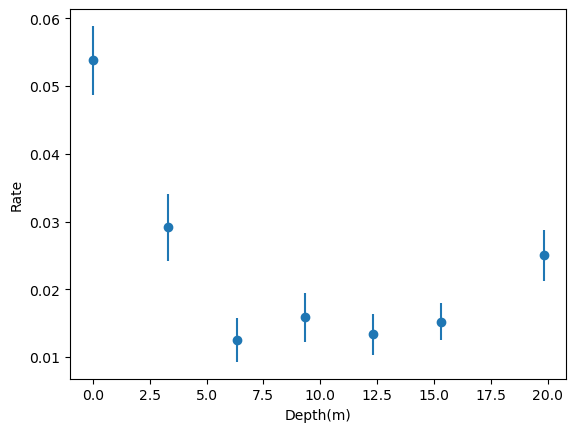

In [112]:
# adding energy cut 
muon_rates_11_25_e_cut = []
muon_rate_errs_11_25_e_cut = []

ws_energy_cut = (75 < data_11_25.energies)

depth_0_rate_e_cut = len(data_11_25.times[mask_0 & ws_energy_cut]) / interval_0
depth_0_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_0 & ws_energy_cut])) / interval_0
muon_rates_11_25_e_cut.append(depth_0_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_0_rate_err_e_cut)

depth_1_rate_e_cut = len(data_11_25.times[mask_1 & ws_energy_cut]) / interval_1
depth_1_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_1 & ws_energy_cut])) / interval_1
muon_rates_11_25_e_cut.append(depth_1_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_1_rate_err_e_cut)

depth_2_rate_e_cut = len(data_11_25.times[mask_2 & ws_energy_cut]) / interval_2
depth_2_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_2 & ws_energy_cut])) / interval_2
muon_rates_11_25_e_cut.append(depth_2_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_2_rate_err_e_cut)

depth_3_rate_e_cut = len(data_11_25.times[mask_3 & ws_energy_cut]) / interval_3
depth_3_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_3 & ws_energy_cut])) / interval_3
muon_rates_11_25_e_cut.append(depth_3_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_3_rate_err_e_cut)

depth_4_rate_e_cut = len(data_11_25.times[mask_4 & ws_energy_cut]) / interval_4
depth_4_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_4 & ws_energy_cut])) / interval_4
muon_rates_11_25_e_cut.append(depth_4_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_4_rate_err_e_cut)

depth_5_rate_e_cut = len(data_11_25.times[mask_5 & ws_energy_cut]) / interval_5
depth_5_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_5 & ws_energy_cut])) / interval_5
muon_rates_11_25_e_cut.append(depth_5_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_5_rate_err_e_cut)

depth_6_rate_e_cut = len(data_11_25.times[mask_6 & ws_energy_cut]) / interval_6
depth_6_rate_err_e_cut = np.sqrt(len(data_11_25.times[mask_6 & ws_energy_cut])) / interval_6
muon_rates_11_25_e_cut.append(depth_6_rate_e_cut)
muon_rate_errs_11_25_e_cut.append(depth_6_rate_err_e_cut)

plt.errorbar(depths_11_25, muon_rates_11_25_e_cut, yerr=muon_rate_errs_11_25_e_cut, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate")

<ErrorbarContainer object of 3 artists>

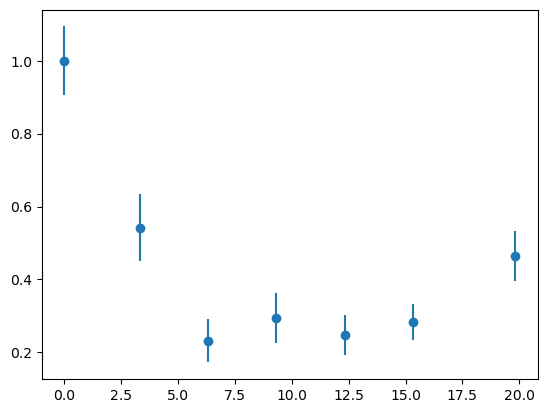

C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:9: RuntimeWarning: invalid value encountered in sqrt
  a_err_11_25 = np.sqrt(a_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:10: RuntimeWarning: invalid value encountered in sqrt
  b_err_11_25 = np.sqrt(b_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:11: RuntimeWarning: invalid value encountered in sqrt
  c_err_11_25 = np.sqrt(c_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:12: RuntimeWarning: invalid value encountered in sqrt
  d_err_11_25 = np.sqrt(d_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:13: RuntimeWarning: invalid value encountered in sqrt
  e_err_11_25 = np.sqrt(e_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:14: RuntimeWarning: invalid value encountered in sqrt
  f_err_11_25 = np.sqrt(f_11_25 - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\219229210.py:15: RuntimeWar

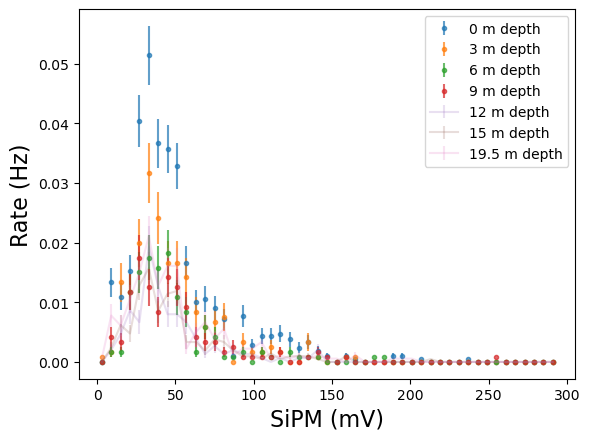

In [15]:
a_11_25, bins = np.histogram(data_11_25.energies[mask_0], bins=np.arange(0, 300, 300/50))
b_11_25, *_ = np.histogram(data_11_25.energies[mask_1], bins=bins)
c_11_25, *_ = np.histogram(data_11_25.energies[mask_2], bins=bins)
d_11_25, *_ = np.histogram(data_11_25.energies[mask_3], bins=bins)
e_11_25, *_ = np.histogram(data_11_25.energies[mask_4], bins=bins)
f_11_25, *_ = np.histogram(data_11_25.energies[mask_5], bins=bins)
g_11_25, *_ = np.histogram(data_11_25.energies[mask_6], bins=bins)

a_err_11_25 = np.sqrt(a_11_25 - 1)
b_err_11_25 = np.sqrt(b_11_25 - 1)
c_err_11_25 = np.sqrt(c_11_25 - 1)
d_err_11_25 = np.sqrt(d_11_25 - 1)
e_err_11_25 = np.sqrt(e_11_25 - 1)
f_err_11_25 = np.sqrt(f_11_25 - 1)
g_err_11_25 = np.sqrt(g_11_25 - 1)

# convert counts to rates 
a_11_25 = a_11_25 / interval_0
b_11_25 = b_11_25 / interval_1
c_11_25 = c_11_25 / interval_2
d_11_25 = d_11_25 / interval_3
e_11_25 = e_11_25 / interval_4
f_11_25 = f_11_25 / interval_5
g_11_25 = g_11_25 / interval_6

centers = 0.5 * (bins[1:] + bins[:-1])
plt.errorbar(centers, a_11_25, yerr=a_err_11_25/interval_0, fmt = '.',label='0 m depth', alpha=0.7)
plt.errorbar(centers, b_11_25, yerr=b_err_11_25/interval_1, fmt = '.' ,label='3 m depth', alpha=0.7)
plt.errorbar(centers, c_11_25, yerr=c_err_11_25/interval_2, fmt = '.',label='6 m depth', alpha=0.7)
plt.errorbar(centers, d_11_25, yerr=d_err_11_25/interval_3, fmt = '.',label='9 m depth', alpha=0.7)
# plt.ylabel('Rate (Hz)')
# plt.xlabel('SiPM (mV)')
# plt.legend()
# plt.show()

plt.errorbar(centers, e_11_25, yerr=e_err_11_25/interval_4, label='12 m depth', alpha=0.2)
plt.errorbar(centers, f_11_25, yerr=f_err_11_25/interval_5, label='15 m depth', alpha=0.2)
plt.errorbar(centers, g_11_25, yerr=g_err_11_25/interval_6, label='19.5 m depth', alpha=0.2)
plt.ylabel('Rate (Hz)', fontsize = 16)
plt.xlabel('SiPM (mV)', fontsize = 16)
plt.legend()
plt.show()


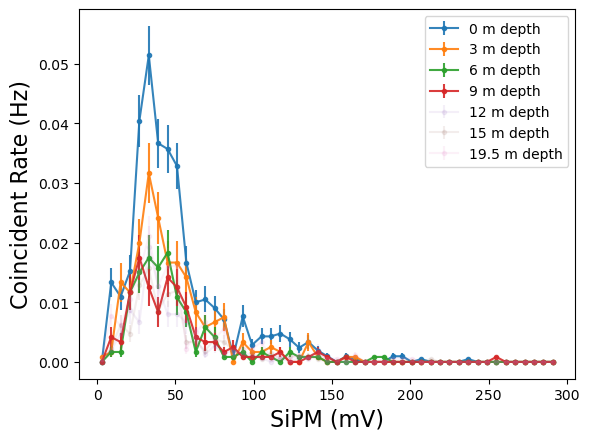

In [16]:
plt.errorbar(centers, a_11_25, yerr=a_err_11_25/interval_0, fmt = '.-',label='0 m depth', alpha=0.9)
plt.errorbar(centers, b_11_25, yerr=b_err_11_25/interval_1, fmt = '.-' ,label='3 m depth', alpha=0.9)
plt.errorbar(centers, c_11_25, yerr=c_err_11_25/interval_2, fmt = '.-',label='6 m depth', alpha=0.9)
plt.errorbar(centers, d_11_25, yerr=d_err_11_25/interval_3, fmt = '.-',label='9 m depth', alpha=0.9)

plt.errorbar(centers, e_11_25, yerr=e_err_11_25/interval_4, fmt = '.-',label='12 m depth', alpha=0.1)
plt.errorbar(centers, f_11_25, yerr=f_err_11_25/interval_5, fmt = '.-',label='15 m depth', alpha=0.1)
plt.errorbar(centers, g_11_25, yerr=g_err_11_25/interval_6, fmt = '.-',label='19.5 m depth', alpha=0.1)
plt.ylabel('Coincident Rate (Hz)', fontsize = 16)
plt.xlabel('SiPM (mV)', fontsize = 16)
plt.legend()
plt.savefig("figures//less_submerged_spectra.png",bbox_inches = 'tight')
plt.show()

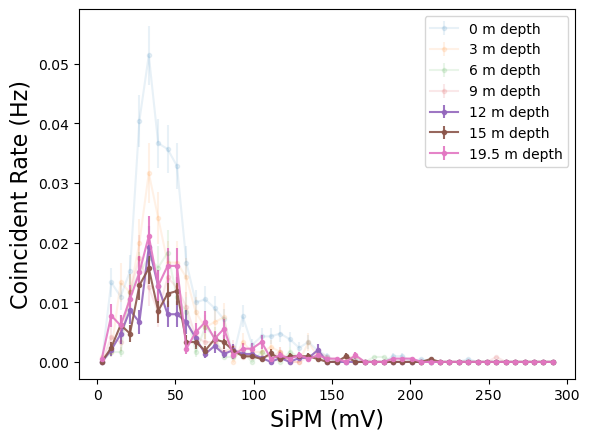

In [17]:
plt.errorbar(centers, a_11_25, yerr=a_err_11_25/interval_0, fmt = '.-',label='0 m depth', alpha=0.1)
plt.errorbar(centers, b_11_25, yerr=b_err_11_25/interval_1, fmt = '.-' ,label='3 m depth', alpha=0.1)
plt.errorbar(centers, c_11_25, yerr=c_err_11_25/interval_2, fmt = '.-',label='6 m depth', alpha=0.1)
plt.errorbar(centers, d_11_25, yerr=d_err_11_25/interval_3, fmt = '.-',label='9 m depth', alpha=0.1)
# plt.ylabel('Rate (Hz)')
# plt.xlabel('SiPM (mV)')
# plt.legend()
# plt.show()

plt.errorbar(centers, e_11_25, yerr=e_err_11_25/interval_4, fmt = '.-',label='12 m depth', alpha=0.9)
plt.errorbar(centers, f_11_25, yerr=f_err_11_25/interval_5, fmt = '.-',label='15 m depth', alpha=0.9)
plt.errorbar(centers, g_11_25, yerr=g_err_11_25/interval_6, fmt = '.-',label='19.5 m depth', alpha=0.9)
plt.ylabel('Coincident Rate (Hz)', fontsize = 16)
plt.xlabel('SiPM (mV)', fontsize = 16)
plt.legend()
plt.savefig("figures//less_submerged_spectra.png",bbox_inches = 'tight')

plt.show()

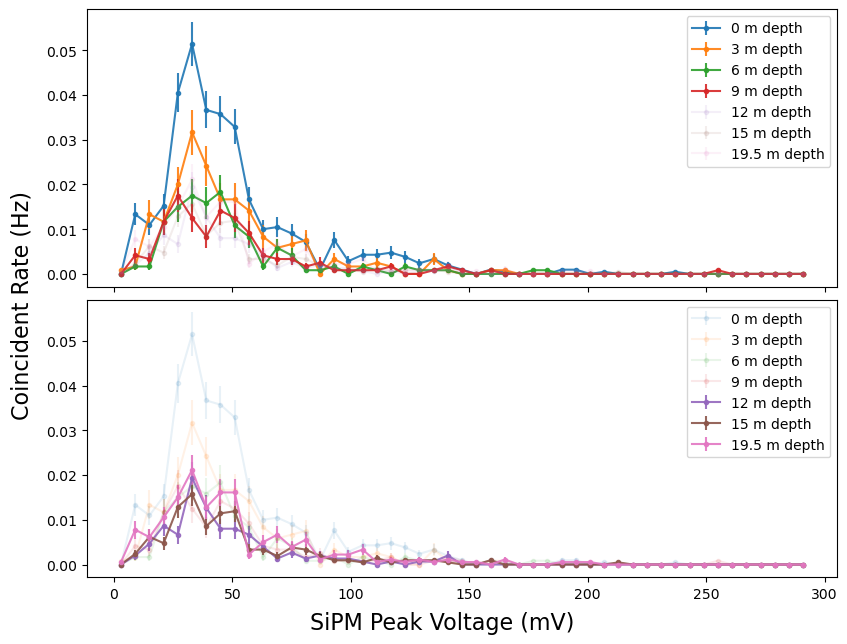

In [18]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 6), constrained_layout=True)

# Top: emphasize shallow depths (0-9 m)
axs[0].errorbar(centers, a_11_25, yerr=a_err_11_25/interval_0, fmt='.-', label='0 m depth', alpha=0.9)
axs[0].errorbar(centers, b_11_25, yerr=b_err_11_25/interval_1, fmt='.-', label='3 m depth', alpha=0.9)
axs[0].errorbar(centers, c_11_25, yerr=c_err_11_25/interval_2, fmt='.-', label='6 m depth', alpha=0.9)
axs[0].errorbar(centers, d_11_25, yerr=d_err_11_25/interval_3, fmt='.-', label='9 m depth', alpha=0.9)
axs[0].errorbar(centers, e_11_25, yerr=e_err_11_25/interval_4, fmt='.-', label='12 m depth', alpha=0.1)
axs[0].errorbar(centers, f_11_25, yerr=f_err_11_25/interval_5, fmt='.-', label='15 m depth', alpha=0.1)
axs[0].errorbar(centers, g_11_25, yerr=g_err_11_25/interval_6, fmt='.-', label='19.5 m depth', alpha=0.1)
axs[0].legend(fontsize=10)
# axs[0].set_title("Coincident spectra — shallow depths emphasized")

# Bottom: emphasize deeper depths (12-19.5 m)
axs[1].errorbar(centers, a_11_25, yerr=a_err_11_25/interval_0, fmt='.-', label='0 m depth', alpha=0.1)
axs[1].errorbar(centers, b_11_25, yerr=b_err_11_25/interval_1, fmt='.-', label='3 m depth', alpha=0.1)
axs[1].errorbar(centers, c_11_25, yerr=c_err_11_25/interval_2, fmt='.-', label='6 m depth', alpha=0.1)
axs[1].errorbar(centers, d_11_25, yerr=d_err_11_25/interval_3, fmt='.-', label='9 m depth', alpha=0.1)
axs[1].errorbar(centers, e_11_25, yerr=e_err_11_25/interval_4, fmt='.-', label='12 m depth', alpha=0.9)
axs[1].errorbar(centers, f_11_25, yerr=f_err_11_25/interval_5, fmt='.-', label='15 m depth', alpha=0.9)
axs[1].errorbar(centers, g_11_25, yerr=g_err_11_25/interval_6, fmt='.-', label='19.5 m depth', alpha=0.9)
axs[1].legend(fontsize=10)
# axs[1].set_title("Coincident spectra — deep depths emphasized")

# Common labels: single x and y for the figure
fig.text(0.5, -0.04, 'SiPM Peak Voltage (mV)', ha='center', fontsize=16)
fig.text(-0.04, 0.5, 'Coincident Rate (Hz)', va='center', rotation='vertical', fontsize=16)

# Save + show
fig.savefig("figures//total_submerged_spectra.png", bbox_inches='tight')
plt.show()


C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:14: RuntimeWarning: invalid value encountered in sqrt
  a_err = np.sqrt(a - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:15: RuntimeWarning: invalid value encountered in sqrt
  b_err = np.sqrt(b - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:16: RuntimeWarning: invalid value encountered in sqrt
  c_err = np.sqrt(c - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:17: RuntimeWarning: invalid value encountered in sqrt
  d_err = np.sqrt(d - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:18: RuntimeWarning: invalid value encountered in sqrt
  e_err = np.sqrt(e - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:19: RuntimeWarning: invalid value encountered in sqrt
  f_err = np.sqrt(f - 1)
C:\Users\megan\AppData\Local\Temp\ipykernel_21748\3574566045.py:20: RuntimeWarning: invalid value encountered in sqrt
  g_err = np.sqrt(g - 1)

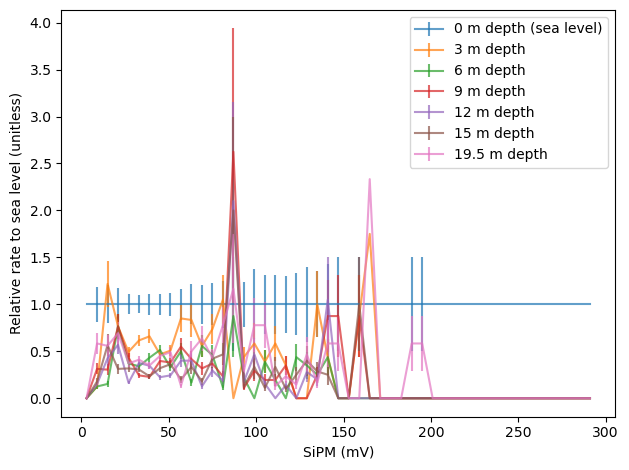

In [19]:
# Compute histograms for each depth with common bins
# Sea level (0 m) used as reference for normalization

# Histograms (counts)
a, bins = np.histogram(data_11_25.energies[mask_0], bins=np.arange(0, 300, 300/50))
b, *_ = np.histogram(data_11_25.energies[mask_1], bins=bins)
c, *_ = np.histogram(data_11_25.energies[mask_2], bins=bins)
d, *_ = np.histogram(data_11_25.energies[mask_3], bins=bins)
e, *_ = np.histogram(data_11_25.energies[mask_4], bins=bins)
f, *_ = np.histogram(data_11_25.energies[mask_5], bins=bins)
g, *_ = np.histogram(data_11_25.energies[mask_6], bins=bins)

# Poisson count uncertainties (keep user's convention)
a_err = np.sqrt(a - 1)
b_err = np.sqrt(b - 1)
c_err = np.sqrt(c - 1)
d_err = np.sqrt(d - 1)
e_err = np.sqrt(e - 1)
f_err = np.sqrt(f - 1)
g_err = np.sqrt(g - 1)

# Convert counts to rates
# intervals are measurement live-times per depth
ar = a / interval_0
br = b / interval_1
cr = c / interval_2
dr = d / interval_3
er = e / interval_4
fr = f / interval_5
gr = g / interval_6

# Rate uncertainties
ar_err = a_err / interval_0
br_err = b_err / interval_1
cr_err = c_err / interval_2
dr_err = d_err / interval_3
er_err = e_err / interval_4
fr_err = f_err / interval_5
gr_err = g_err / interval_6

# Normalize all spectra relative to sea level (0 m)
ref = ar
ref_err = ar_err

# Helper: ratio with error propagation; handles zeros safely
def ratio_with_error(y, yerr, ref, referr):
    r = np.divide(y, ref, out=np.zeros_like(y, dtype=float), where=ref != 0)
    # fractional terms
    frac_y = np.zeros_like(yerr, dtype=float) #np.divide(yerr, y, out=np.zeros_like(yerr, dtype=float), where=y != 0)
    frac_ref = np.divide(referr, ref, out=np.zeros_like(referr, dtype=float), where=ref != 0)
    r_err = r * np.sqrt(frac_y**2 + frac_ref**2)
    return r, r_err

# For the reference curve, show it as 1 with its fractional uncertainty band
an = np.ones_like(ref, dtype=float)
an_err = np.divide(ref_err, ref, out=np.zeros_like(ref_err, dtype=float), where=ref != 0)

bn, bn_err = ratio_with_error(br, br_err, ref, ref_err)
cn, cn_err = ratio_with_error(cr, cr_err, ref, ref_err)
dn, dn_err = ratio_with_error(dr, dr_err, ref, ref_err)
en, en_err = ratio_with_error(er, er_err, ref, ref_err)
fn, fn_err = ratio_with_error(fr, fr_err, ref, ref_err)
gn, gn_err = ratio_with_error(gr, gr_err, ref, ref_err)

# Plot
centers = 0.5 * (bins[1:] + bins[:-1])
plt.errorbar(centers, an, yerr=an_err, label='0 m depth (sea level)', alpha=0.7)
plt.errorbar(centers, bn, yerr=bn_err, label='3 m depth', alpha=0.7)
plt.errorbar(centers, cn, yerr=cn_err, label='6 m depth', alpha=0.7)
plt.errorbar(centers, dn, yerr=dn_err, label='9 m depth', alpha=0.7)
plt.errorbar(centers, en, yerr=en_err, label='12 m depth', alpha=0.7)
plt.errorbar(centers, fn, yerr=fn_err, label='15 m depth', alpha=0.7)
plt.errorbar(centers, gn, yerr=gn_err, label='19.5 m depth', alpha=0.7)

plt.ylabel('Relative rate to sea level (unitless)')
plt.xlabel('SiPM (mV)')
plt.legend()
plt.tight_layout()

13.266853171774768 103085.2543799002
16.458906605922554 104007.87287015945
16.87016233766234 104105.0073051948
17.08526645768025 104151.07056426333
17.138925373134327 104110.19808955224
16.245517890772128 103717.70032015066
17.180720145852323 104156.38649954423


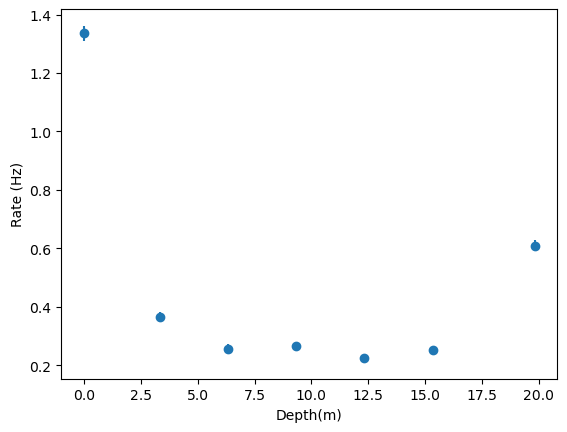

Text(0, 0.5, 'Counts')

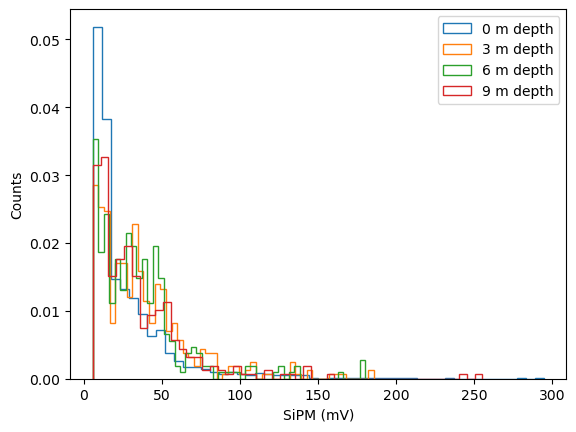

In [20]:
total_rates_11_25 = []
total_rate_errs_11_25 = []
data_11_25_all = CosmicWatchMeasurement(data_file="submersion\\Top_Cos_Watch_11_25_25.txt", only_coincident=False)

mask_0 = (0 * 60 < data_11_25_all.times) & (data_11_25_all.times < 35*60)
depth_0 = 0
interval_0 = (35*60 - 0*60)
depth_0_rate = len(data_11_25_all.times[mask_0]) / interval_0
depth_0_rate_err = np.sqrt(len(data_11_25_all.times[mask_0])) / interval_0
total_rates_11_25.append(depth_0_rate)
total_rate_errs_11_25.append(depth_0_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_0]), np.mean(data_11_25_all.pressures[mask_0]))

mask_1 = (35*60 < data_11_25_all.times) & (data_11_25_all.times < 55*60)
depth_1 = 3 + 0.34 - 0.014 
interval_1 = (55*60 - 35*60)
depth_1_rate = len(data_11_25_all.times[mask_1]) / interval_1
depth_1_rate_err = np.sqrt(len(data_11_25_all.times[mask_1])) / interval_1
total_rates_11_25.append(depth_1_rate)
total_rate_errs_11_25.append(depth_1_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_1]), np.mean(data_11_25_all.pressures[mask_1]))

mask_2 = (55*60 < data_11_25_all.times) & (data_11_25_all.times < 75*60)
depth_2 = 6 + 0.34 - 0.014 
interval_2 = (75*60 - 55*60)
depth_2_rate = len(data_11_25_all.times[mask_2]) / interval_2
depth_2_rate_err = np.sqrt(len(data_11_25_all.times[mask_2])) / interval_2
total_rates_11_25.append(depth_2_rate)
total_rate_errs_11_25.append(depth_2_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_2]), np.mean(data_11_25_all.pressures[mask_2]))

mask_3 = (75*60 < data_11_25_all.times) & (data_11_25_all.times < 95*60)
depth_3 = 9 + 0.34 - 0.014 
interval_3 = (95*60 - 75*60)
depth_3_rate = len(data_11_25_all.times[mask_3]) / interval_3 
depth_3_rate_err = np.sqrt(len(data_11_25_all.times[mask_3])) / interval_3
total_rates_11_25.append(depth_3_rate)
total_rate_errs_11_25.append(depth_3_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_3]), np.mean(data_11_25_all.pressures[mask_3]))


mask_4 = (95*60 < data_11_25_all.times) & (data_11_25_all.times < 120*60)
depth_4 = 12 + 0.34 - 0.014 
interval_4 = (120*60 - 95*60)
depth_4_rate = len(data_11_25_all.times[mask_4]) / interval_4
depth_4_rate_err = np.sqrt(len(data_11_25_all.times[mask_4])) / interval_4
total_rates_11_25.append(depth_4_rate)
total_rate_errs_11_25.append(depth_4_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_4]), np.mean(data_11_25_all.pressures[mask_4]))

mask_5 = (120*60 < data_11_25_all.times) & (data_11_25_all.times < 155*60)
depth_5 = 15 + 0.34 - 0.014 
interval_5 = (155*60 - 120*60)
depth_5_rate = len(data_11_25_all.times[mask_5]) / interval_5
depth_5_rate_err = np.sqrt(len(data_11_25_all.times[mask_5])) / interval_5
total_rates_11_25.append(depth_5_rate)
total_rate_errs_11_25.append(depth_5_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_5]), np.mean(data_11_25_all.pressures[mask_5]))

mask_6 = (168*60 < data_11_25_all.times) & (data_11_25_all.times < 198*60)
depth_6 = 19.5 + 0.34 - 0.014 
interval_6 = (198*60 - 168*60)
depth_6_rate = len(data_11_25_all.times[mask_6]) / interval_6
depth_6_rate_err = np.sqrt(len(data_11_25_all.times[mask_6])) / interval_6
total_rates_11_25.append(depth_6_rate)
total_rate_errs_11_25.append(depth_6_rate_err)
print(np.mean(data_11_25_all.temperatures[mask_6]), np.mean(data_11_25_all.pressures[mask_6]))

plt.errorbar(depths_11_25, total_rates_11_25, yerr=total_rate_errs_11_25, fmt='o')
plt.xlabel("Depth(m)")
plt.ylabel("Rate (Hz)")
plt.show()

plt.hist(data_11_25_all.energies[mask_0], bins=50, histtype='step', label = '0 m depth',density=True)
plt.hist(data_11_25_all.energies[mask_1], bins=50, histtype='step', label = '3 m depth', density=True)
plt.hist(data_11_25_all.energies[mask_2], bins=50, histtype='step', label = '6 m depth', density=True)
plt.hist(data_11_25_all.energies[mask_3], bins=50, histtype='step', label = '9 m depth',density=True)
# plt.hist(data_11_25_all.energies[mask_4], bins=50, histtype='step', label = '12.5 m depth', density=True)
# plt.hist(data_11_25_all.energies[mask_5], bins=50, histtype='step', label = '15 m depth', density=True)
# plt.hist(data_11_25_all.energies[mask_6], bins=50, histtype='step', label = '19.5 m depth', density=True)

plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

# All Days

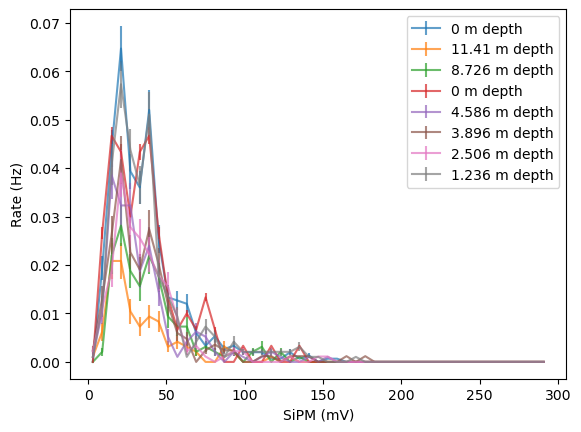

In [21]:
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),a_11_13, yerr = a_err_11_13/interval_0,label = '0 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),b_11_13, yerr = b_err_11_13/interval_1, label = '11.41 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),c_11_13, yerr = c_err_11_13/interval_2, label = '8.726 m depth', alpha = 0.7)

plt.errorbar(0.5 * (bins[1:] + bins[:-1]),a_11_19, yerr = a_err_11_19/interval_0,label = '0 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),b_11_19, yerr = b_err_11_19/interval_1, label = '4.586 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),c_11_19, yerr = c_err_11_19/interval_2, label = '3.896 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),d_11_19, yerr = d_err_11_19/interval_3, label = '2.506 m depth', alpha = 0.7)
plt.errorbar(0.5 * (bins[1:] + bins[:-1]),e_11_19, yerr = e_err_11_19/interval_4, label = '1.236 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),f, yerr = f_err/interval_5, label = '15 m depth', alpha = 0.7)
# plt.errorbar(0.5 * (bins[1:] + bins[:-1]),g, yerr = g_err/interval_6, label = '19.5 m depth', alpha = 0.7)

plt.ylabel('Rate (Hz)')
plt.xlabel('SiPM (mV)')
plt.legend()

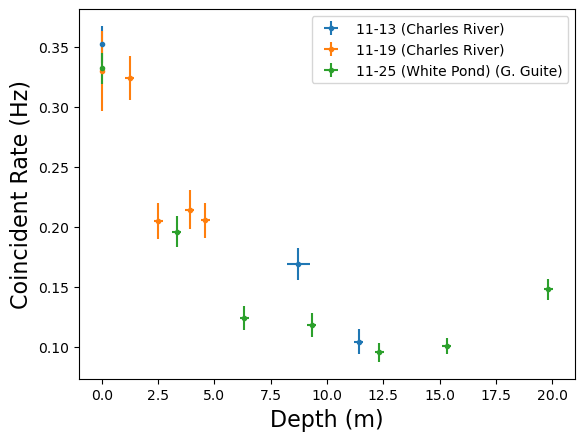

In [22]:
plt.errorbar(depths_11_13, np.array(muon_rates_11_13), xerr = [0,0.2,0.5], yerr=np.array(muon_rate_errs_11_13), fmt='.', label = '11-13 (Charles River)')
plt.errorbar(depths_11_19, np.array(muon_rates_11_19), xerr = [0,0.2,0.2,0.2,0.2], yerr=np.array(muon_rate_errs_11_19), fmt='.', label = '11-19 (Charles River)')
plt.errorbar(depths_11_25, np.array(muon_rates_11_25), xerr = [0,0.2,0.2,0.2,0.2,0.2,0.2], yerr=np.array(muon_rate_errs_11_25), fmt='.', label = '11-25 (White Pond) (G. Guite)')

plt.xlabel("Depth (m)", fontsize = 16)
plt.ylabel("Coincident Rate (Hz)", fontsize = 16)
plt.legend()
plt.savefig("figures//raw_coincidents.png", bbox_inches = 'tight')

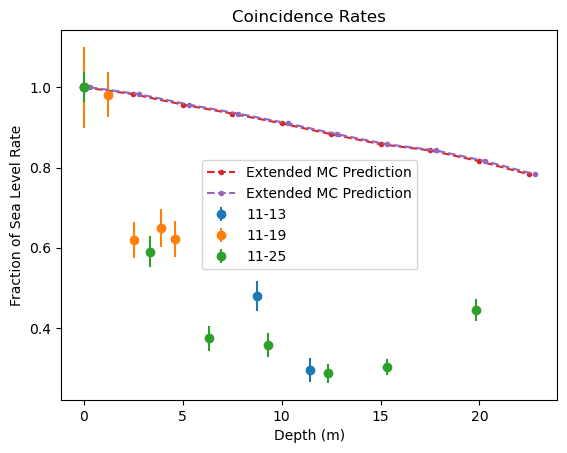

In [63]:
plt.errorbar(depths_11_13, np.array(muon_rates_11_13)/np.max(muon_rates_11_13), yerr=np.array(muon_rate_errs_11_13)/np.max(muon_rates_11_13), fmt='o', label = '11-13')
plt.errorbar(depths_11_19, np.array(muon_rates_11_19)/np.max(muon_rates_11_19), yerr=np.array(muon_rate_errs_11_19)/np.max(muon_rates_11_19), fmt='o', label = '11-19')
plt.errorbar(depths_11_25, np.array(muon_rates_11_25)/np.max(muon_rates_11_25), yerr=np.array(muon_rate_errs_11_25)/np.max(muon_rates_11_25), fmt='o', label = '11-25')
# plt.plot(range(0,25,5),np.array(hit_rates)[:5]/hit_rates[0], marker = '.', linestyle = '--', label = 'Monte Carlo Prediction')
plt.plot(np.arange(0,25,2.5),np.array(more_hit_rates)/more_hit_rates[0], marker = '.', linestyle = '--', label = 'Extended MC Prediction')
plt.plot(np.arange(0.3,25+.3,2.5),np.array(more_hit_rates)/more_hit_rates[0], marker = '.', linestyle = '--', label = 'Extended MC Prediction')

plt.title("Coincidence Rates")
plt.xlabel("Depth (m)")
plt.ylabel("Fraction of Sea Level Rate")
plt.legend()

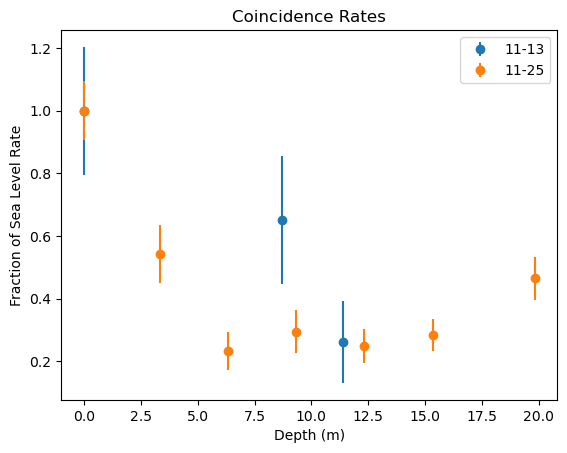

In [120]:
plt.errorbar(depths_11_13, np.array(muon_rates_11_13_e_cut)/np.max(muon_rates_11_13_e_cut), yerr=np.array(muon_rate_errs_11_13_e_cut)/np.max(muon_rates_11_13_e_cut), fmt='o', label = '11-13')
# plt.errorbar(depths_11_19, np.array(muon_rates_11_19_e_cut)/np.max(muon_rates_11_19_e_cut), yerr=np.array(muon_rate_errs_11_19_e_cut)/np.max(muon_rates_11_19_e_cut), fmt='o', label = '11-19')
plt.errorbar(depths_11_25, np.array(muon_rates_11_25_e_cut)/np.max(muon_rates_11_25_e_cut), yerr=np.array(muon_rate_errs_11_25_e_cut)/np.max(muon_rates_11_25_e_cut), fmt='o', label = '11-25')

plt.title("Coincidence Rates")
plt.xlabel("Depth (m)")
plt.ylabel("Fraction of Sea Level Rate")
plt.legend()

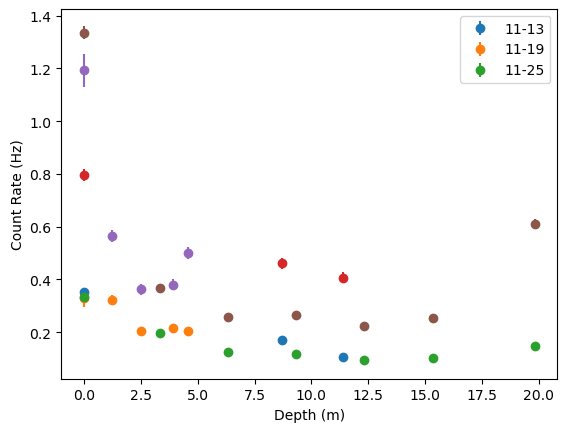

In [25]:
plt.errorbar(depths_11_13, np.array(muon_rates_11_13), yerr=np.array(muon_rate_errs_11_13), fmt='o', label = '11-13')
plt.errorbar(depths_11_19, np.array(muon_rates_11_19), yerr=np.array(muon_rate_errs_11_19), fmt='o', label = '11-19')
plt.errorbar(depths_11_25, np.array(muon_rates_11_25), yerr=np.array(muon_rate_errs_11_25), fmt='o', label = '11-25')

plt.errorbar(depths_11_13, np.array(total_rates_11_13), yerr=np.array(total_rate_errs_11_13), fmt='o')
plt.errorbar(depths_11_19, np.array(total_rates_11_19), yerr=np.array(total_rate_errs_11_19), fmt='o')
plt.errorbar(depths_11_25, np.array(total_rates_11_25), yerr=np.array(total_rate_errs_11_25), fmt='o')

plt.xlabel("Depth (m)")
plt.ylabel("Count Rate (Hz)")

plt.legend()

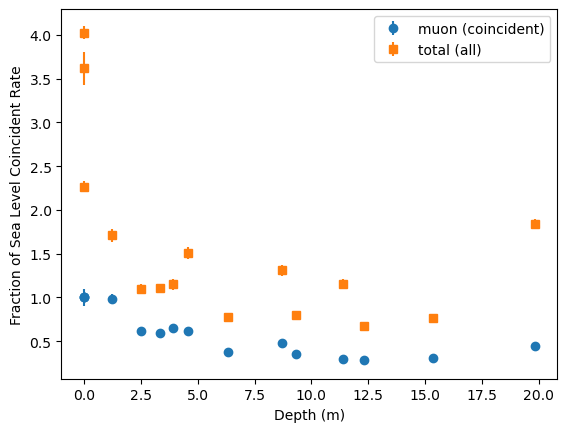

In [26]:
# plt.errorbar(depths_11_13, np.array(muon_rates_11_13)/np.max(muon_rates_11_13), yerr=np.array(muon_rate_errs_11_13)/np.max(muon_rates_11_13), fmt='o', label = '11-13')
# plt.errorbar(depths_11_19, np.array(muon_rates_11_19)/np.max(muon_rates_11_19), yerr=np.array(muon_rate_errs_11_19)/np.max(muon_rates_11_19), fmt='o', label = '11-19')
# plt.errorbar(depths_11_25, np.array(muon_rates_11_25)/np.max(muon_rates_11_25), yerr=np.array(muon_rate_errs_11_25)/np.max(muon_rates_11_25), fmt='o', label = '11-25')

# plt.errorbar(depths_11_13, np.array(total_rates_11_13)/np.max(total_rates_11_13), yerr=np.array(total_rate_errs_11_13)/np.max(total_rates_11_13), fmt='o', label = '11-13')
# plt.errorbar(depths_11_19, np.array(total_rates_11_19)/np.max(total_rates_11_19), yerr=np.array(total_rate_errs_11_19)/np.max(total_rates_11_19), fmt='o', label = '11-19')
# plt.errorbar(depths_11_25, np.array(total_rates_11_25)/np.max(total_rates_11_25), yerr=np.array(total_rate_errs_11_25)/np.max(total_rates_11_25), fmt='o', label = '11-25')

# plt.xlabel("Depth (m)")
# plt.ylabel("Fraction of Sea Level Rate")
# plt.legend()
# plt.show()

# combining stuff such that it is normalized by coinicident sea level rate at each day
# combine muon (coincident) datasets
muon_depths = np.concatenate([np.array(depths_11_13), np.array(depths_11_19), np.array(depths_11_25)])
muon_rates = np.concatenate([np.array(muon_rates_11_13)/np.max(muon_rates_11_13), np.array(muon_rates_11_19)/np.max(muon_rates_11_19), np.array(muon_rates_11_25)/np.max(muon_rates_11_25)])
muon_errs  = np.concatenate([np.array(muon_rate_errs_11_13)/np.max(muon_rates_11_13), np.array(muon_rate_errs_11_19)/np.max(muon_rates_11_19), np.array(muon_rate_errs_11_25)/np.max(muon_rates_11_25)])

# sort by depth (ascending) and reorder rates/errors to keep indices aligned
sort_idx = np.argsort(muon_depths)
muon_depths = muon_depths[sort_idx]
muon_rates = muon_rates[sort_idx]
muon_errs = muon_errs[sort_idx]

# combine total (all) datasets
total_depths = np.concatenate([np.array(depths_11_13), np.array(depths_11_19), np.array(depths_11_25)])
total_rates  = np.concatenate([np.array(total_rates_11_13)/np.max(muon_rates_11_13), np.array(total_rates_11_19)/np.max(muon_rates_11_19), np.array(total_rates_11_25)/np.max(muon_rates_11_25)])
total_errs   = np.concatenate([np.array(total_rate_errs_11_13)/np.max(muon_rates_11_13), np.array(total_rate_errs_11_19)/np.max(muon_rates_11_19), np.array(total_rate_errs_11_25)/np.max(muon_rates_11_25)])

sort_idx = np.argsort(total_depths)
total_depths = total_depths[sort_idx]
total_rates = total_rates[sort_idx]
total_errs = total_errs[sort_idx]

plt.errorbar(muon_depths, muon_rates, yerr=muon_errs, fmt='o', label='muon (coincident)')
plt.errorbar(total_depths, total_rates, yerr=total_errs, fmt='s', label='total (all)')

plt.xlabel("Depth (m)")
plt.ylabel("Fraction of Sea Level Coincident Rate")
plt.legend()
plt.show()

In [27]:
muon_depths

array([ 0.   ,  0.   ,  0.   ,  1.236,  2.506,  3.326,  3.896,  4.586,
        6.326,  8.726,  9.326, 11.41 , 12.326, 15.326, 19.826])

In [28]:
# 15 cm of lead is equivalent shielding to
15

15

0.00028385535420538677
[ 3.06460389  0.07128915  0.08838773 -2.0643395 ]
[2.04475075 0.0342344  0.0539039  2.05538095]


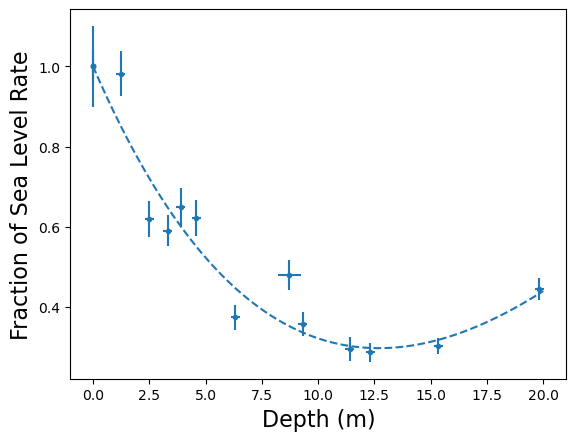

In [141]:
def exp_plus_lin(x,A,l,m,b):
    return A*np.exp(-x*l) + m*x+b

popt1, pcov1 = curve_fit(exp_plus_lin,muon_depths,muon_rates,[0,0,0,0],sigma=muon_errs, absolute_sigma=True)
chi2_value = np.sum(((exp_plus_lin(muon_depths, *popt1) - muon_rates) / muon_errs) ** 2)
dof = len(muon_rates) - len(popt1)
reduced_chi2 = chi2_value / dof
chi2_prob = chi2.cdf(chi2_value, dof)
p_val1 = 1 - chi2_prob

overplot_x1 = np.linspace(0, 20, num=200)
overplot_y1 = exp_plus_lin(overplot_x1, *popt1)

xerr = [0,0,0,0.2,0.2,0.2,0.2,0.2,0.2,0.5,0.2,0.2,0.2,0.2,0.2]

plt.errorbar(muon_depths, muon_rates, xerr = xerr, yerr=muon_errs, fmt='.', label='muon (coincident)')
plt.plot(overplot_x1, overplot_y1, linestyle ='--', color = 'tab:blue')
# plt.title("Coincidence Rates")
plt.xlabel("Depth (m)", fontsize = 16)
plt.ylabel("Fraction of Sea Level Rate", fontsize = 16)
print(p_val1)
print(popt1)
print(np.sqrt(np.diag(pcov1)))

# plt.savefig("figures//fitted_normalized.png",bbox_inches = 'tight')

1.0390892035694321e-08
[0.70738126 0.27030177 0.31654408]
[0.02835335 0.02729824 0.01563523]


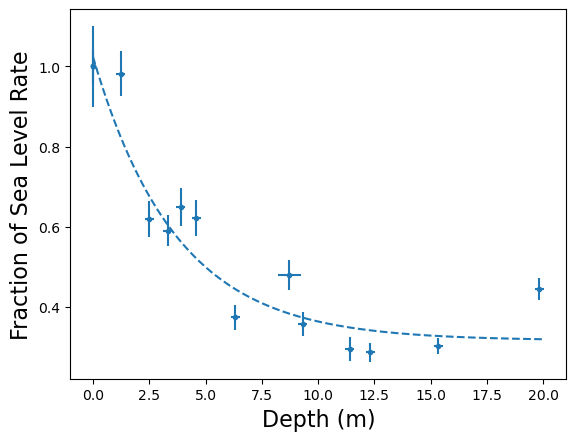

In [ ]:
def exp_plus_const(x,A,l,c):
    return A*np.exp(-x*l) + c

popt1, pcov1 = curve_fit(exp_plus_const,muon_depths,muon_rates,[0,0,0],sigma=muon_errs, absolute_sigma=True)
chi2_value = np.sum(((exp_plus_const(muon_depths, *popt1) - muon_rates) / muon_errs) ** 2)
dof = len(muon_rates) - len(popt1)
reduced_chi2 = chi2_value / dof
chi2_prob = chi2.cdf(chi2_value, dof)
p_val1 = 1 - chi2_prob

overplot_x1 = np.linspace(0, 20, num=200)
overplot_y1 = exp_plus_const(overplot_x1, *popt1)

xerr = [0,0,0,0.2,0.2,0.2,0.2,0.2,0.2,0.5,0.2,0.2,0.2,0.2,0.2]

plt.errorbar(muon_depths, muon_rates, xerr = xerr, yerr=muon_errs, fmt='.', label='muon (coincident)')
plt.plot(overplot_x1, overplot_y1, linestyle ='--', color = 'tab:blue')
# plt.title("Coincidence Rates")
plt.xlabel("Depth (m)", fontsize = 16)
plt.ylabel("Fraction of Sea Level Rate", fontsize = 16)
print(p_val1)
print(popt1)
print(np.sqrt(np.diag(pcov1)))

plt.savefig("figures//fitted_normalized.png",bbox_inches = 'tight')

0.0
[ 0.65198536 20.26703103  1.19349192  2.03139165]
[0.0180317  1.29665435 0.         0.51255325]


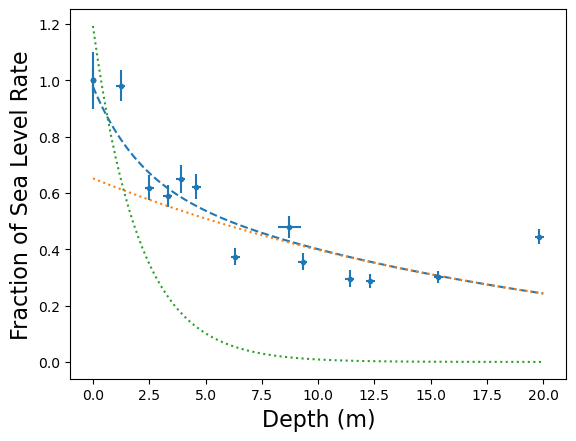

In [124]:

def two_exp(x,A1,l1,A2,l2):
    return (A1)*np.exp(-x*1/l1) + (A1)*0.5*np.exp(-x*1/l2)

def exp(x,A,l):
    return A*np.exp(-x*1/l)

popt1, pcov1 = curve_fit(two_exp,muon_depths,muon_rates,[0.5,0.2,0.5,0.05],sigma=muon_errs, absolute_sigma=True, maxfev=1000000, bounds = (0.0, np.inf))
chi2_value = np.sum(((two_exp(muon_depths, *popt1) - muon_rates) / muon_errs) ** 2)
dof = len(muon_rates) - len(popt1)
reduced_chi2 = chi2_value / dof
chi2_prob = chi2.cdf(chi2_value, dof)
p_val1 = 1 - chi2_prob

overplot_x1 = np.linspace(0, 20, num=200)
overplot_y1 = two_exp(overplot_x1, *popt1)

overplot_y2 = exp(overplot_x1, popt1[0], popt1[1])
overplot_y3 = exp(overplot_x1, popt1[2], popt1[3])

xerr = [0,0,0,0.2,0.2,0.2,0.2,0.2,0.2,0.5,0.2,0.2,0.2,0.2,0.2]

plt.errorbar(muon_depths, muon_rates, xerr = xerr, yerr=muon_errs, fmt='.', label='muon (coincident)')
plt.plot(overplot_x1, overplot_y1, linestyle ='--', color = 'tab:blue')
plt.plot(overplot_x1, overplot_y2, linestyle =':', color = 'tab:orange', label = 'EM Component')
plt.plot(overplot_x1, overplot_y3, linestyle =':', color = 'tab:green', label = 'Muon Component')
# plt.title("Coincidence Rates")
plt.xlabel("Depth (m)", fontsize = 16)
plt.ylabel("Fraction of Sea Level Rate", fontsize = 16)
print(p_val1)
print(popt1)
print(np.sqrt(np.diag(pcov1)))
plt.savefig("figures//fitted_normalized.png",bbox_inches = 'tight')

5.2630201308190294e-09


Text(0, 0.5, 'Fraction of Sea Level Rate')

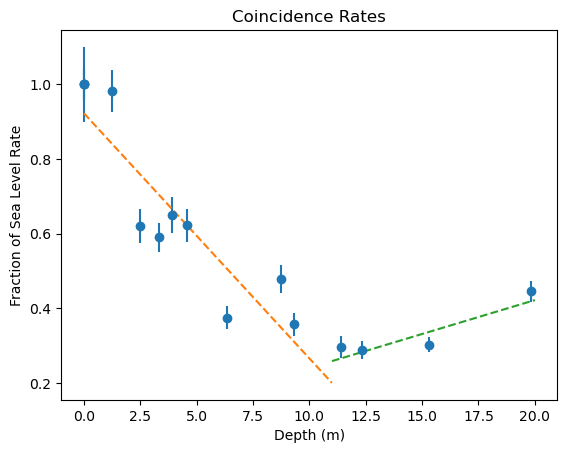

In [30]:
def linear(x,m,b):
    return m*x+b
cut_1  = 11
popt1, pcov1 = curve_fit(linear,muon_depths[:cut_1],muon_rates[:cut_1],[0,0],sigma=muon_errs[:cut_1], absolute_sigma=True)
chi2_value = np.sum(((linear(muon_depths[:cut_1], *popt1) - muon_rates[:cut_1]) / muon_errs[:cut_1]) ** 2)
dof = len(muon_rates) - len(popt1)
reduced_chi2 = chi2_value / dof
chi2_prob = chi2.cdf(chi2_value, dof)
p_val1 = 1 - chi2_prob

overplot_x1 = np.linspace(0, cut_1, num=200)
overplot_y1 = linear(overplot_x1, *popt1)

popt2, pcov2 = curve_fit(linear,muon_depths[cut_1:],muon_rates[cut_1:],[0,0],sigma=muon_errs[cut_1:], absolute_sigma=True)
chi2_value = np.sum(((linear(muon_depths[cut_1:], *popt1) - muon_rates[cut_1:]) / muon_errs[cut_1:]) ** 2)
dof = len(muon_rates) - len(popt1)
reduced_chi2 = chi2_value / dof
chi2_prob = chi2.cdf(chi2_value, dof)
p_val2 = 1 - chi2_prob

overplot_x2 = np.linspace(cut_1, 20, num=200)
overplot_y2 = linear(overplot_x2, *popt2)

plt.errorbar(muon_depths, muon_rates, yerr=muon_errs, fmt='o', label='muon (coincident)')
plt.plot(overplot_x1, overplot_y1, label='Linear Fit', linestyle ='--')
plt.plot(overplot_x2, overplot_y2, label='Linear Fit', linestyle ='--')

print(p_val1)

plt.title("Coincidence Rates")
plt.xlabel("Depth (m)")
plt.ylabel("Fraction of Sea Level Rate")

# Monte Carlo Attempt

In [31]:
# do monte carlo to simulate stuff (detector acceptance? when the muonic component drops off?)
# draw from 0 m sea level spectrum
# thats the energy coming in
# based on the depth, the muon has some path length
# and some energy loss along that path length
# then i guess just figure out where the muon stops
# or how much energy it deposits in the detector

# also how does the kinetic energy of muon correlate with the SiPM readout
# / what does the SiPM readout actually mean

# simulate a b

# in section 3.3 of https://iopscience.iop.org/article/10.1088/0305-4616/10/7/013/pdf
# they use monte carlo to simulate the detector acceptance

In [32]:
# path_length = depth

In [33]:
# Do a Monte Carlo to determine effective detection area
# Generate random events based on x, y, theta (zenith that also takes into account expected angular dist (cos^2(theta))), phi (azimuthal, uniform)
# See how many of those events pass through the detector and are coincident
# Then effective area = (number of detected events / number of generated events) * area of generation plane

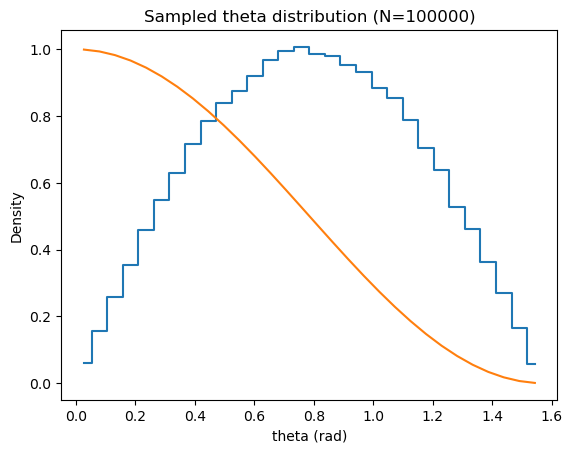

In [34]:
def geometric_pdf(theta):
    return np.cos(theta) * np.sin(theta)

def physical_pdf(theta):
    return 4 * np.cos(theta)**2

def sample_theta(max_theta=np.pi/2):
    # Upper bound on pdf: max of 4 cos^3 θ sin θ on [0, max_theta]
    # For max_theta = pi/2, the maximum is at θ = arctan(1/sqrt(3)) ~ 0.955
    max_pdf = 1.3   # same constant as in the C code, OK for rejection

    while True:
        theta = max_theta * np.random.random()      # candidate
        pdf_val = geometric_pdf(theta)
        threshold = max_pdf * np.random.random()    # rejection threshold
        if threshold < pdf_val:
            return theta

# Run sampling 1000 times and plot histogram
M = 100000
thetas = [sample_theta() for _ in range(M)]

a, bins = np.histogram(thetas, bins=30)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
plt.plot(bin_centers, a / np.sum(a) / (bins[1]-bins[0]), drawstyle='steps-mid')
plt.plot(bin_centers, [math.cos(angle)**2 for angle in bin_centers], label='Expected Dependence')
plt.xlabel('theta (rad)')
plt.ylabel('Density')
plt.title(f'Sampled theta distribution (N={M})')
plt.show()


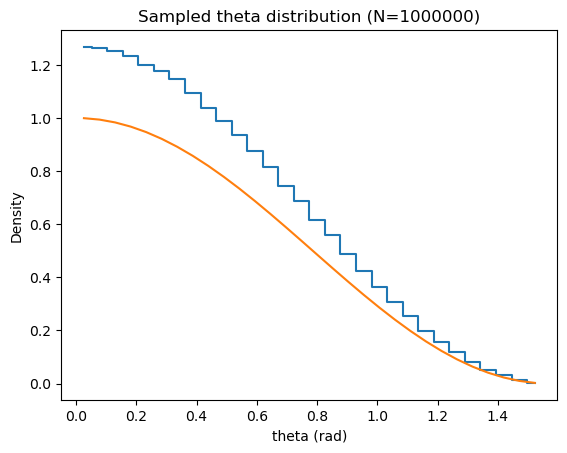

In [35]:
def sample_theta_cos2():
    while True:
        theta = np.random.random() * np.pi/2
        if np.random.random() < np.cos(theta)**2:
            return theta
        
M = 1000000
thetas = [sample_theta_cos2() for _ in range(M)]

a, bins = np.histogram(thetas, bins=30)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
plt.plot(bin_centers, a / np.sum(a) / (bins[1]-bins[0]), drawstyle='steps-mid')
plt.plot(bin_centers, [math.cos(angle)**2 for angle in bin_centers], label='Expected Dependence')
plt.xlabel('theta (rad)')
plt.ylabel('Density')
plt.title(f'Sampled theta distribution (N={M})')
plt.show()

Text(0.5, 0, 'Energy (GeV)')

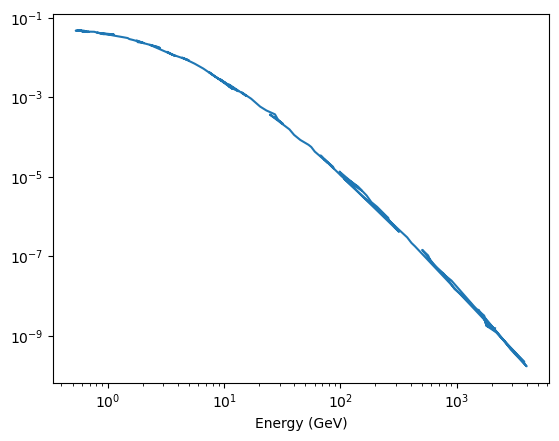

In [ ]:
import csv

with open('submersion//plot-data.csv', 'r') as read_obj:
    energies = []
    spec = []
    # Return a reader object which will
    # iterate over lines in the given csvfile
    csv_reader = csv.reader(read_obj)
    first = True
    for row in csv_reader:
        if first:
            first = False
            continue
        energies.append(((float(row[0]))**2 + 0.105658**2)**0.5 + 2.5)
        spec.append(float(row[1]))
spec = spec/np.sum(spec)
plt.plot(energies,spec)
plt.xscale('log')
plt.yscale('log')
# plt.xlim(0,5)
plt.xlabel('Energy (GeV)')
# plt.axvline(4)

In [139]:
print(np.sum(spec*energies))

1.7923435250344397


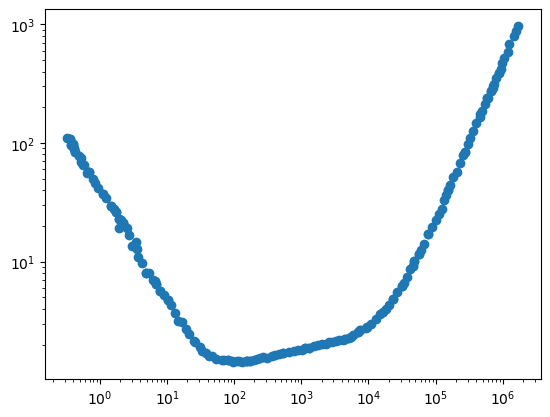

In [38]:
with open('submersion//plot-data_1.csv', 'r') as read_obj:
    dEdx_vals = []
    E_vals = []
    # Return a reader object which will
    # iterate over lines in the given csvfile
    csv_reader = csv.reader(read_obj)
    first = True
    for row in csv_reader:
        if first:
            first = False
            continue
        E_vals.append(float(row[0]))
        dEdx_vals.append(float(row[1]))

plt.scatter(E_vals,dEdx_vals)
plt.xscale('log')
plt.yscale('log')

In [39]:

# prepare numpy arrays and sort by energy (required for reliable interpolation)
E_arr = np.array(E_vals, dtype=float)
dEdx_arr = np.array(dEdx_vals, dtype=float)
order = np.argsort(E_arr)
E_arr = E_arr[order]
dEdx_arr = dEdx_arr[order]

def step_energy_loss(E, x, dx):  # inputs: E in MeV, x and dx in cm

    while E > 0.1 and x > 0:
        # choose the appropriate segment for interpolation based on current E
        if E < 100.0:
            low, high = 0.1, 100.0
        elif E < 1e6:
            low, high = 100.0, 1e6
        else:
            low, high = 1e6, np.inf

        mask = (E_arr >= low) & (E_arr <= high)

        # if there are not enough points in the chosen range, fall back to the full dataset
        if mask.sum() >= 1:
            subset_E = E_arr[mask]
            subset_dEdx = dEdx_arr[mask]
        else:
            subset_E = E_arr
            subset_dEdx = dEdx_arr

        # interpolate dE/dx for current E (will use endpoint values if E outside subset_E)
        dEdx = np.interp(E, subset_E, subset_dEdx)
        # print(E, x, dEdx)
        # apply step
        dE = dEdx * dx
        E -= dE
        x -= dx

    return E, x

In [140]:
def simulate_event(D=1, depth = 0):
    # sample positions on top scintillator
    # xi = np.random.uniform(-2.5,2.5)  # in cm
    # yi = np.random.uniform(-2.5,2.5)  # in cm
    # sample angles
    theta = sample_theta_cos2()
    phi = 2*np.pi*np.random.random()
    # assume beam all intersects (0,0) (center of top scintillator)

    # direction opposite to muon
    nx = -np.sin(theta)*np.cos(phi)
    ny = -np.sin(theta)*np.sin(phi)
    nz = -np.cos(theta)

    # to bottom detector
    d = D / np.cos(theta)

    # final coordinates
    xf = d*nx
    yf = d*ny

    geo_hit = (abs(xf) <= 2.5) and (abs(yf) <= 2.5)

    # energy loss
    # rate = -0.22 # GeV/m
    energy_est = np.random.choice(energies, p=spec) # GeV
    path_length = depth/np.cos(theta)
    if depth == 0:
        return geo_hit, theta, phi

    final_energy, remaining_path =step_energy_loss(energy_est*1000,path_length*100, 50)
    final_energy = final_energy/1000 # MeV back to GeV
    remaining_path = remaining_path/100 # cm back to m

    hit = geo_hit and (final_energy > 1/10) # FINAL ENERGY LOWEST SET HERE in GeV

    return hit, theta, phi

# Example: run 1 million
N = 10000
hit_cnt = 0
hit_rates = []
hits = []
misses = []

for depth in range(0,200,5):
    hit_cnt = 0
    hits = []
    misses = []
    for _ in range(N):
        hit, *event = simulate_event(depth = depth)
        if hit:
            hit_cnt += 1
            hits.append(event)
        else:
            misses.append(event)
    hit_rates.append(hit_cnt/N)
    print("Depth =", depth, "Hit fraction =", hit_cnt/N)


Depth = 0 Hit fraction = 0.9794
Depth = 5 Hit fraction = 0.459
Depth = 10 Hit fraction = 0.1643
Depth = 15 Hit fraction = 0.0853
Depth = 20 Hit fraction = 0.0467
Depth = 25 Hit fraction = 0.0368
Depth = 30 Hit fraction = 0.0289
Depth = 35 Hit fraction = 0.0235
Depth = 40 Hit fraction = 0.0146
Depth = 45 Hit fraction = 0.0125
Depth = 50 Hit fraction = 0.0063
Depth = 55 Hit fraction = 0.0045
Depth = 60 Hit fraction = 0.0046
Depth = 65 Hit fraction = 0.0026
Depth = 70 Hit fraction = 0.0023
Depth = 75 Hit fraction = 0.002
Depth = 80 Hit fraction = 0.0015
Depth = 85 Hit fraction = 0.0012
Depth = 90 Hit fraction = 0.0008
Depth = 95 Hit fraction = 0.0005
Depth = 100 Hit fraction = 0.0008
Depth = 105 Hit fraction = 0.0005
Depth = 110 Hit fraction = 0.0003
Depth = 115 Hit fraction = 0.0
Depth = 120 Hit fraction = 0.0004
Depth = 125 Hit fraction = 0.0001
Depth = 130 Hit fraction = 0.0
Depth = 135 Hit fraction = 0.0
Depth = 140 Hit fraction = 0.0001
Depth = 145 Hit fraction = 0.0002
Depth = 150 H

In [60]:
N = 50000
hit_cnt = 0
more_hit_rates = []
hits = []
misses = []

for depth in np.arange(0,25,2.5):
    hit_cnt = 0
    hits = []
    misses = []
    for _ in range(N):
        hit, *event = simulate_event(depth = depth)
        if hit:
            hit_cnt += 1
            hits.append(event)
        else:
            misses.append(event)
    more_hit_rates.append(hit_cnt/N)
    print("Depth =", depth, "Hit fraction =", hit_cnt/N)


Depth = 0.0 Hit fraction = 0.98372
Depth = 2.5 Hit fraction = 0.9666
Depth = 5.0 Hit fraction = 0.9412
Depth = 7.5 Hit fraction = 0.9191
Depth = 10.0 Hit fraction = 0.89514
Depth = 12.5 Hit fraction = 0.86864
Depth = 15.0 Hit fraction = 0.84416
Depth = 17.5 Hit fraction = 0.82884
Depth = 20.0 Hit fraction = 0.8025
Depth = 22.5 Hit fraction = 0.7702


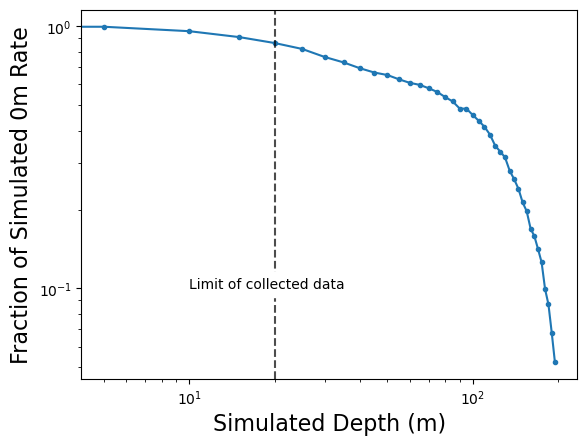

In [ ]:
plt.plot(range(0,200,5),np.array(hit_rates)/hit_rates[0])
plt.scatter(range(0,200,5),np.array(hit_rates)/hit_rates[0], marker = '.')
plt.ylabel('Fraction of Simulated 0m Rate', fontsize = 16)
plt.xlabel('Simulated Depth (m)', fontsize = 16)
plt.axvline(20,linestyle = '--', alpha = 0.7, color = 'black')
plt.text(10,0.1, "Limit of collected data", bbox = dict(facecolor= 'white', edgecolor = 'white'))
plt.xscale('log')
plt.yscale('log')
plt.savefig('figures//monte_carlo.png', bbox_inches = 'tight')